# Pert × Pathway × Drug significance heatmaps

Build pert × pathway × drug significance/effect tensors from per-(group, pathway, batch) OLS CSVs and plot a 2×8 grid of heatmaps:

- **Row 1**: 7 batch1 drugs (`drug:target_gene` interactions vs `DMSO_round2`) + `DMSO_round2` panel (`target_gene` main effects, batch1 model)
- **Row 2**: 7 batch2 drugs (interactions vs `DMSO_round2_batch2`) + `DMSO_round2_batch2` panel (main effects, batch2 model)

Each panel cell ∈ {-1, 0, +1} = sign(β) × (pval < threshold).

Filters (applied sequentially):
- perts: keep those with ≥ `pert_min_sig` significant interactions (counted across all 14 non-DMSO drugs and all complete pathways)
- pathways: keep those with ≥ `path_min_sig` significant tests (counted across kept perts and 14 non-DMSO drugs)

Inputs: `/home/beraslan/Projects/ChemoGeneticScreens/PertPathwayDrugInteraction/<group>/<pathway>__{batch1,batch2}.csv`

## Imports & constants

In [1]:
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from scipy.cluster.hierarchy import linkage, leaves_list

warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
BATCH_DRUGS = {
    'batch1': ['AR-A014418', 'AZD4573', 'CHIR-98014', 'Lexibulin', 'PP121',
                'Romidepsin', 'Stattic', 'DMSO_round2'],
    'batch2': ['Bisindolylmaleimide-I', 'DG-172', 'JTE-607', 'LDN-193189',
                'LY2090314', 'NSC95397', 'VX-11e', 'DMSO_round2_batch2'],
}
DMSO_OF_BATCH = {'batch1': 'DMSO_round2', 'batch2': 'DMSO_round2_batch2'}

DIFF_CMAP = ListedColormap(['cornflowerblue', 'white', 'crimson'])

## Helper functions

In [3]:
def discover_complete_pathways(input_dir: Path):
    """Return sorted list of pathways with both-batch CSVs in every group."""
    groups = sorted([d.name for d in input_dir.iterdir()
                      if d.is_dir() and d.name.startswith('group_')])
    if not groups:
        raise SystemExit(f'no group_* dirs in {input_dir}')

    pathways_by_gb = {}
    for g in groups:
        for batch in ('batch1', 'batch2'):
            files = list((input_dir / g).glob(f'*__{batch}.csv'))
            pathways_by_gb[(g, batch)] = {
                f.name.replace(f'__{batch}.csv', '') for f in files
            }

    sets = list(pathways_by_gb.values())
    common = set.intersection(*sets) if sets else set()
    n_total = len(set.union(*sets)) if sets else 0
    print(f'Groups detected: {len(groups)}')
    print(f'Pathways with full coverage ({len(groups)} groups × 2 batches = '
          f'{len(groups)*2} CSVs): {len(common)} / {n_total}')
    return groups, sorted(common)

In [4]:
def load_ols_long(input_dir: Path, groups, pathways):
    """Load all relevant rows (target_gene main effects + drug:target_gene
    interactions) into a single long DataFrame."""
    if not pathways:
        raise SystemExit('no complete pathways yet — wait for more groups to finish')
    rows = []
    t0 = time.time()
    expected = len(groups) * len(pathways) * 2
    n_done = 0
    for g in groups:
        for batch in ('batch1', 'batch2'):
            for p in pathways:
                fp = input_dir / g / f'{p}__{batch}.csv'
                if not fp.exists():
                    continue
                df = pd.read_csv(fp, dtype={'drug': str, 'target_gene': str})
                df = df[df['term_type'].isin(('target_gene', 'drug:target_gene'))]
                if df.empty:
                    continue
                df['group']   = g
                df['batch']   = batch
                df['pathway'] = p
                rows.append(df)
                n_done += 1
                if n_done % 2000 == 0:
                    print(f'  loaded {n_done:,}/{expected:,} CSVs '
                          f'({time.time()-t0:.0f}s)', flush=True)
    long_df = pd.concat(rows, ignore_index=True)
    print(f'  loaded {n_done:,}/{expected:,} CSVs in {time.time()-t0:.0f}s '
          f'({len(long_df):,} rows total)')
    return long_df

In [5]:
def build_tensors(long_df):
    """Pivot long_df into wide pert × (drug, pathway) tables for both
    interactions and DMSO main effects."""
    # Drug:target_gene interactions: drug = the non-DMSO drug
    ints = long_df[long_df['term_type'] == 'drug:target_gene'].copy()
    ints = ints.dropna(subset=['drug', 'target_gene'])

    # target_gene main effects: assign drug = DMSO of that batch
    mes = long_df[long_df['term_type'] == 'target_gene'].copy()
    mes = mes.dropna(subset=['target_gene'])
    mes['drug'] = mes['batch'].map(DMSO_OF_BATCH)

    combo = pd.concat([ints, mes], ignore_index=True)
    print(f'Long combined rows: {len(combo):,}')
    print(f'  drugs: {combo["drug"].nunique()}'
          f'  perts: {combo["target_gene"].nunique()}'
          f'  pathways: {combo["pathway"].nunique()}')

    beta = combo.pivot_table(values='beta',
                              index='target_gene',
                              columns=['drug', 'pathway'])
    pval = combo.pivot_table(values='pvalue',
                              index='target_gene',
                              columns=['drug', 'pathway'])
    return beta, pval

In [6]:
def to_sign_sig(beta, pval, p_threshold):
    """Cell ∈ {-1, 0, +1} = sign(β) when pvalue < threshold else 0."""
    sig = (pval < p_threshold).fillna(False).values
    sn  = np.sign(beta.fillna(0).values).astype(np.int8)
    out = (sn * sig.astype(np.int8))
    return pd.DataFrame(out, index=beta.index, columns=beta.columns)

In [7]:
def filter_perts_pathways(sig, pert_min_sig, path_min_sig):
    """Two-stage filter: perts → pathways."""
    non_dmso = [d for d in sig.columns.get_level_values('drug').unique()
                 if d not in DMSO_OF_BATCH.values()]
    sig_int = sig.loc[:, sig.columns.get_level_values('drug').isin(non_dmso)]

    # Per pert: number of (drug, pathway) cells with |sig|=1
    pert_counts = sig_int.abs().sum(axis=1)
    keep_perts = pert_counts[pert_counts >= pert_min_sig].index.tolist()
    print(f'Perts kept: {len(keep_perts)} / {sig_int.shape[0]} '
          f'(min sig interactions per pert ≥ {pert_min_sig})')
    if not keep_perts:
        raise SystemExit('no perts pass the filter — lower pert_min_sig')

    # Per pathway: number of (drug, kept_pert) cells with |sig|=1
    sig_int_kp = sig_int.loc[keep_perts]
    by_path = sig_int_kp.abs().groupby(level='pathway', axis=1).sum().sum(axis=0)
    keep_paths = by_path[by_path >= path_min_sig].index.tolist()
    print(f'Pathways kept: {len(keep_paths)} / {len(by_path)} '
          f'(min sig tests per pathway ≥ {path_min_sig})')
    if not keep_paths:
        raise SystemExit('no pathways pass the filter — lower path_min_sig')

    return keep_perts, keep_paths

In [8]:
def hier_order(mat, axis):
    """Return hierarchical-clustering leaf order along the given axis."""
    if mat.shape[axis] <= 1:
        return mat.axes[axis].tolist()
    arr = mat.values if axis == 0 else mat.values.T
    arr = np.nan_to_num(arr, nan=0.0)
    Z = linkage(arr, method='average', metric='euclidean')
    return [mat.axes[axis][i] for i in leaves_list(Z)]

In [9]:
def plot_grid(sig, beta, keep_perts, keep_paths, out_fp, p_threshold,
              pert_order_ref=None, path_order_ref=None):
    """Plot the 2 × 8 per-drug grid.

    If `pert_order_ref` / `path_order_ref` are given (e.g. from the
    Section 5 diagnostic clustermap), use that ordering for any
    perts/pathways that appear in both the reference and the filtered
    set. Anything in the filtered set but not in the reference is
    appended at the end, ordered by hierarchical clustering on the
    leftover subset.
    """
    # Subset
    sig_kp = sig.loc[keep_perts]
    sig_kp = sig_kp.loc[:, sig_kp.columns.get_level_values('pathway').isin(keep_paths)]
    beta_kp = beta.loc[keep_perts]
    beta_kp = beta_kp.loc[:, beta_kp.columns.get_level_values('pathway').isin(keep_paths)]

    # Pert ordering
    if pert_order_ref is not None:
        keep_set = set(keep_perts)
        in_ref = [p for p in pert_order_ref if p in keep_set]
        not_in_ref = [p for p in keep_perts if p not in set(pert_order_ref)]
        if not_in_ref:
            extra = hier_order(sig_kp.loc[not_in_ref], axis=0)
            pert_order = in_ref + list(extra)
        else:
            pert_order = in_ref
        print(f'Pert order: {len(in_ref)} from clustermap reference + '
              f'{len(not_in_ref)} appended (clustered on leftover subset)')
    else:
        pert_order = hier_order(sig_kp, axis=0)

    # Pathway ordering
    sigabs_by_path = sig_kp.abs().groupby(level='pathway', axis=1).sum()
    if path_order_ref is not None:
        keep_set = set(keep_paths)
        in_ref = [p for p in path_order_ref if p in keep_set]
        not_in_ref = [p for p in keep_paths if p not in set(path_order_ref)]
        if not_in_ref:
            extra = hier_order(sigabs_by_path[not_in_ref], axis=1)
            path_order = in_ref + list(extra)
        else:
            path_order = in_ref
        print(f'Pathway order: {len(in_ref)} from clustermap reference + '
              f'{len(not_in_ref)} appended (clustered on leftover subset)')
    else:
        path_order = hier_order(sigabs_by_path[keep_paths], axis=1)

    fig, axes = plt.subplots(2, 8, figsize=(34, 14))
    fig.subplots_adjust(left=0.04, right=0.98, top=0.92, bottom=0.05,
                        wspace=0.06, hspace=0.18)

    for row_i, batch in enumerate(['batch1', 'batch2']):
        non_dmso_drugs = [d for d in BATCH_DRUGS[batch] if d != DMSO_OF_BATCH[batch]]
        dmso = DMSO_OF_BATCH[batch]
        for col_i, drug in enumerate(non_dmso_drugs):
            ax = axes[row_i, col_i]
            try:
                sub = sig_kp.xs(drug, level='drug', axis=1)
            except KeyError:
                ax.set_axis_off(); continue
            sub = sub.reindex(index=pert_order, columns=path_order)
            sns.heatmap(sub, ax=ax, cmap=DIFF_CMAP, vmin=-1, vmax=1, center=0,
                         cbar=False, xticklabels=False, yticklabels=False)
            ax.set_title(f'{drug}\n(vs {dmso})', fontsize=12)

        # Last column: DMSO main-effects panel
        ax = axes[row_i, 7]
        try:
            sub = sig_kp.xs(dmso, level='drug', axis=1)
            sub = sub.reindex(index=pert_order, columns=path_order)
            sns.heatmap(sub, ax=ax, cmap=DIFF_CMAP, vmin=-1, vmax=1, center=0,
                         cbar=False, xticklabels=False, yticklabels=False)
            ax.set_title(f'{dmso}\n(pert main effect)', fontsize=12,
                          fontweight='bold')
        except KeyError:
            ax.set_axis_off()

    fig.supxlabel(f'{len(path_order):,} Pathways', fontsize=18)
    fig.supylabel(f'{len(pert_order):,} Perturbations', fontsize=18)
    fig.legend(
        handles=[
            Patch(facecolor='crimson',          label=f'+1 sig positive (p<{p_threshold})'),
            Patch(facecolor='white', edgecolor='gray', label='0 not significant'),
            Patch(facecolor='cornflowerblue',   label=f'−1 sig negative (p<{p_threshold})'),
        ],
        loc='upper center', bbox_to_anchor=(0.5, 0.99), ncol=3, fontsize=12,
        frameon=False,
    )
    out_fp.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_fp, dpi=120, bbox_inches='tight')
    print(f'Wrote {out_fp}')

    # Also save the underlying tensors for downstream reuse
    parquet_dir = out_fp.parent / 'tensors'
    parquet_dir.mkdir(parents=True, exist_ok=True)
    sig_kp.to_parquet(parquet_dir / 'sign_sig.parquet')
    beta_kp.to_parquet(parquet_dir / 'beta.parquet')
    pd.Series(pert_order).to_csv(parquet_dir / 'pert_order.csv', index=False, header=['pert'])
    pd.Series(path_order).to_csv(parquet_dir / 'pathway_order.csv', index=False, header=['pathway'])
    print(f'Wrote tensors + orderings to {parquet_dir}')
    return fig, pert_order, path_order

In [10]:
def plot_diagnostic_histograms(sig, p_threshold, output_dir,
                                  pert_min_paths_with_sig=10, path_col_min=10):
    """Three diagnostic figures:

    A. Histogram of the total number of significant drug:target_gene
       interaction terms per perturbation, aggregated across all
       non-DMSO drugs × pathways.

    B. Per-drug histograms of significant pathway-interaction counts per
       perturbation. One panel per non-DMSO drug; bars show how many
       perturbations have N significant pathways at that drug.

    B′. Per-drug histograms of significant perturbation-interaction
       counts per pathway. One panel per non-DMSO drug; bars show
       how many pathways have N significant perturbations at that
       drug. (Transpose of B.)

    C. Clustermap of (perturbation × pathway) where the cell value is
       the number of non-DMSO drug contexts in which that (pert,
       pathway) interaction is significant. Rows filtered to perts
       with a significant interaction in ≥ `pert_min_paths_with_sig`
       pathways; cols filtered by col_sum > `path_col_min`.
       Hierarchical clustering with dendrograms is shown.

    D. Per-drug sign-significance heatmaps using the SAME row and
       column order as Plot C, one panel per non-DMSO drug. Cells
       are +1 (sig positive), 0 (not significant), −1 (sig
       negative).
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # Restrict to non-DMSO drugs (the interaction terms)
    non_dmso = sorted(
        d for d in sig.columns.get_level_values('drug').unique()
        if d not in DMSO_OF_BATCH.values()
    )
    sig_int = sig.loc[:, sig.columns.get_level_values('drug').isin(non_dmso)]
    n_paths = sig_int.columns.get_level_values('pathway').nunique()

    # ----- Plot A: total sig interactions per perturbation -----
    pert_total_sig = sig_int.abs().sum(axis=1)
    pos_per_pert   = (sig_int ==  1).sum(axis=1)
    neg_per_pert   = (sig_int == -1).sum(axis=1)

    fig_a, ax_a = plt.subplots(figsize=(9, 5))
    ax_a.hist(pert_total_sig.values, bins=60, color='steelblue',
              edgecolor='white')
    ax_a.axvline(pert_total_sig.median(), color='crimson', linestyle='--',
                 linewidth=1.2,
                 label=f'median = {pert_total_sig.median():.0f}')
    ax_a.axvline(pert_total_sig.mean(),   color='black',  linestyle=':',
                 linewidth=1.2,
                 label=f'mean = {pert_total_sig.mean():.1f}')
    ax_a.set_xlabel('# significant (drug × pathway) interaction terms per perturbation')
    ax_a.set_ylabel('# perturbations')
    ax_a.set_title(
        f'Total significant interactions per perturbation\n'
        f'({len(non_dmso)} drugs × {n_paths} pathways, p < {p_threshold})'
    )
    ax_a.legend()
    fig_a.tight_layout()
    out_a = output_dir / 'diagnostic_sig_interactions_per_pert.png'
    fig_a.savefig(out_a, dpi=120, bbox_inches='tight')
    print(f'Wrote {out_a}')
    print(f'  perturbations: {len(pert_total_sig)}')
    print(f'  total sig interactions:  median={pert_total_sig.median():.0f}'
          f'  mean={pert_total_sig.mean():.1f}'
          f'  max={pert_total_sig.max()}'
          f'  zero={int((pert_total_sig == 0).sum())}/{len(pert_total_sig)}')
    print(f'  positive sig: median={pos_per_pert.median():.0f}'
          f'  mean={pos_per_pert.mean():.1f}'
          f'  max={pos_per_pert.max()}')
    print(f'  negative sig: median={neg_per_pert.median():.0f}'
          f'  mean={neg_per_pert.mean():.1f}'
          f'  max={neg_per_pert.max()}')

    # ----- Plot B: per-drug, per-pert # sig pathways -----
    drug_counts = {}
    for d in non_dmso:
        sub = sig_int.xs(d, level='drug', axis=1)
        drug_counts[d] = sub.abs().sum(axis=1)

    n_drugs = len(non_dmso)
    n_cols = 4
    n_rows = (n_drugs + n_cols - 1) // n_cols
    fig_b, axes = plt.subplots(n_rows, n_cols,
                                figsize=(4 * n_cols, 2.8 * n_rows),
                                sharex=True, sharey=True)
    axes = axes.flatten() if n_drugs > 1 else [axes]

    max_count = max(c.max() for c in drug_counts.values())
    bins = np.linspace(0, max(max_count, 1), 40)

    for ax, d in zip(axes, non_dmso):
        counts = drug_counts[d]
        ax.hist(counts.values, bins=bins, color='steelblue', edgecolor='white')
        med = counts.median()
        ax.axvline(med, color='crimson', linestyle='--', linewidth=1)
        n_active = int((counts > 0).sum())
        ax.set_title(f'{d}', fontsize=11)
        ax.text(0.97, 0.95,
                f'perts>0: {n_active}/{len(counts)}\n'
                f'median: {med:.0f}\n'
                f'max: {counts.max()}',
                transform=ax.transAxes, fontsize=8, ha='right', va='top',
                bbox=dict(facecolor='white', alpha=0.75,
                          edgecolor='lightgray'))

    for ax in axes[n_drugs:]:
        ax.set_axis_off()

    fig_b.supxlabel('# significant pathway interactions per perturbation', fontsize=12)
    fig_b.supylabel('# perturbations', fontsize=12)
    fig_b.suptitle(
        f'Per-drug distribution of significant pathway interactions per perturbation '
        f'(p < {p_threshold})',
        fontsize=13, y=1.00,
    )
    fig_b.tight_layout()
    out_b = output_dir / 'diagnostic_sig_pathways_per_pert_by_drug.png'
    fig_b.savefig(out_b, dpi=120, bbox_inches='tight')
    print(f'Wrote {out_b}')

    # Per-drug summary table
    summary = pd.DataFrame({
        'n_perts_with_any_sig':
            {d: int((c > 0).sum()) for d, c in drug_counts.items()},
        'median_sig_paths_per_pert':
            {d: float(c.median()) for d, c in drug_counts.items()},
        'mean_sig_paths_per_pert':
            {d: float(c.mean())   for d, c in drug_counts.items()},
        'max_sig_paths_in_any_pert':
            {d: int(c.max())      for d, c in drug_counts.items()},
    }).sort_values('n_perts_with_any_sig', ascending=False)
    print()
    print('Per-drug summary:')
    print(summary.to_string())

    # ----- Plot B′: per-drug histograms of # sig perts per pathway -----
    drug_pert_counts = {}
    for d in non_dmso:
        sub = sig_int.xs(d, level='drug', axis=1)
        # per pathway: # of perts with a significant interaction at this drug
        drug_pert_counts[d] = sub.abs().sum(axis=0)

    fig_bp, axes_bp = plt.subplots(n_rows, n_cols,
                                    figsize=(4 * n_cols, 2.8 * n_rows),
                                    sharex=True, sharey=True)
    axes_bp = axes_bp.flatten() if n_drugs > 1 else [axes_bp]

    max_p = max(c.max() for c in drug_pert_counts.values())
    bins_p = np.linspace(0, max(max_p, 1), 40)

    for ax, d in zip(axes_bp, non_dmso):
        counts = drug_pert_counts[d]
        ax.hist(counts.values, bins=bins_p, color='darkorange', edgecolor='white')
        med = counts.median()
        ax.axvline(med, color='crimson', linestyle='--', linewidth=1)
        n_active = int((counts > 0).sum())
        ax.set_title(f'{d}', fontsize=11)
        ax.text(0.97, 0.95,
                f'paths>0: {n_active}/{len(counts)}\n'
                f'median: {med:.0f}\n'
                f'max: {counts.max()}',
                transform=ax.transAxes, fontsize=8, ha='right', va='top',
                bbox=dict(facecolor='white', alpha=0.75,
                          edgecolor='lightgray'))

    for ax in axes_bp[n_drugs:]:
        ax.set_axis_off()

    fig_bp.supxlabel('# significant perturbation interactions per pathway', fontsize=12)
    fig_bp.supylabel('# pathways', fontsize=12)
    fig_bp.suptitle(
        f'Per-drug distribution of significant perturbation interactions per pathway '
        f'(p < {p_threshold})',
        fontsize=13, y=1.00,
    )
    fig_bp.tight_layout()
    out_bp = output_dir / 'diagnostic_sig_perts_per_pathway_by_drug.png'
    fig_bp.savefig(out_bp, dpi=120, bbox_inches='tight')
    print(f'Wrote {out_bp}')

    # Per-drug summary table (pathway side)
    summary_paths = pd.DataFrame({
        'n_pathways_with_any_sig':
            {d: int((c > 0).sum()) for d, c in drug_pert_counts.items()},
        'median_sig_perts_per_path':
            {d: float(c.median()) for d, c in drug_pert_counts.items()},
        'mean_sig_perts_per_path':
            {d: float(c.mean())   for d, c in drug_pert_counts.items()},
        'max_sig_perts_in_any_path':
            {d: int(c.max())      for d, c in drug_pert_counts.items()},
    }).sort_values('n_pathways_with_any_sig', ascending=False)
    print()
    print('Per-drug summary (pathway side):')
    print(summary_paths.to_string())

    # ----- Plot C: pert × pathway count-of-drug-contexts clustermap -----
    # For each (pert, pathway): count drug contexts where the cell is sig.
    drug_context_count = (
        sig_int.abs()
        .groupby(level='pathway', axis=1)
        .sum()                           # (perts × pathways), value ∈ [0, n_drugs]
    )

    # Row filter: keep perts that have a significant interaction in
    # ≥ pert_min_paths_with_sig pathways (any drug context).
    pert_n_paths_with_sig = (drug_context_count > 0).sum(axis=1)
    keep_rows = pert_n_paths_with_sig[
        pert_n_paths_with_sig >= pert_min_paths_with_sig
    ].index

    # Col filter: keep pathways with col_sum > path_col_min
    col_sums = drug_context_count.sum(axis=0)
    keep_cols = col_sums[col_sums > path_col_min].index

    print()
    print(f'Plot C filter:')
    print(f'  rows: pert has sig in ≥ {pert_min_paths_with_sig} pathways'
          f'  → {len(keep_rows)}/{drug_context_count.shape[0]} perts')
    print(f'  cols: col_sum > {path_col_min}'
          f'  → {len(keep_cols)}/{drug_context_count.shape[1]} pathways')

    if len(keep_rows) == 0 or len(keep_cols) == 0:
        print('  (no rows/cols pass filter — skipping plot C)')
        return fig_a, fig_b, summary, None

    sub = drug_context_count.loc[keep_rows, keep_cols]

    # Use seaborn clustermap for visible dendrograms + automatic clustering.
    # Hierarchical clustering on Euclidean distance; average linkage.
    cg = sns.clustermap(
        sub,
        cmap='magma_r',
        vmin=0, vmax=len(non_dmso),
        figsize=(min(0.18 * len(keep_cols) + 4, 28),
                  min(0.12 * len(keep_rows) + 4, 28)),
        method='average',
        metric='euclidean',
        xticklabels=False,
        yticklabels=False,
        cbar_kws={'label': '# drug contexts with sig interaction'},
        dendrogram_ratio=(0.10, 0.12),
        col_cluster=True,
        row_cluster=True,
    )
    cg.ax_heatmap.set_xlabel(
        f'{len(keep_cols)} pathways (col_sum > {path_col_min})'
    )
    cg.ax_heatmap.set_ylabel(
        f'{len(keep_rows)} perturbations  '
        f'(sig in ≥ {pert_min_paths_with_sig} pathways)'
    )
    cg.figure.suptitle(
        f'Cross-drug consistency of significant interactions  (p < {p_threshold})\n'
        f'cell = # of {len(non_dmso)} drug contexts where the (pert, pathway) '
        f'interaction is significant',
        y=1.02,
    )
    out_c = output_dir / 'diagnostic_pert_pathway_drug_context_count.png'
    cg.savefig(out_c, dpi=120, bbox_inches='tight')
    print(f'Wrote {out_c}')
    print(f'  values range: {int(sub.values.min())}..{int(sub.values.max())}'
          f'  (max possible = {len(non_dmso)})')

    # Reorder sub to match the clustering for downstream use
    pert_order = sub.index[cg.dendrogram_row.reordered_ind].tolist()
    path_order = sub.columns[cg.dendrogram_col.reordered_ind].tolist()
    sub_ordered = sub.loc[pert_order, path_order]

    # ----- Plot D: per-drug sign-significance heatmaps (same row/col order) -----
    # For each non-DMSO drug, slice the sign-significance matrix for that drug,
    # reindex to the clustermap's pert × pathway order, and tile into a grid.
    n_drugs = len(non_dmso)
    n_cols_d = 7
    n_rows_d = (n_drugs + n_cols_d - 1) // n_cols_d
    fig_d, axes_d = plt.subplots(
        n_rows_d, n_cols_d,
        figsize=(20, 25),
        squeeze=False,
    )
    fig_d.subplots_adjust(left=0.04, right=0.98, top=0.92, bottom=0.05,
                           wspace=0.06, hspace=0.18)

    # Sort drugs by batch, then within batch by name (so panels are grouped sensibly)
    drug_order_d = sum(
        ([d for d in BATCH_DRUGS[b]
          if d != DMSO_OF_BATCH[b] and d in non_dmso]
         for b in ('batch1', 'batch2')),
        [],
    )

    for ax, drug in zip(axes_d.flat, drug_order_d):
        try:
            d_sub = sig_int.xs(drug, level='drug', axis=1)
        except KeyError:
            ax.set_axis_off()
            continue
        d_sub = d_sub.reindex(index=pert_order, columns=path_order)
        sns.heatmap(
            d_sub, ax=ax, cmap=DIFF_CMAP, vmin=-1, vmax=1, center=0,
            cbar=False, xticklabels=False, yticklabels=False,
        )
        ax.set_title(drug, fontsize=10)

    # Hide any unused panels
    for ax in axes_d.flat[len(drug_order_d):]:
        ax.set_axis_off()

    fig_d.supxlabel(f'{len(path_order)} pathways (clustermap order)', fontsize=12)
    fig_d.supylabel(f'{len(pert_order)} perturbations (clustermap order)', fontsize=12)
    fig_d.suptitle(
        f'Per-drug sign-significance of (pert × pathway) interactions  '
        f'(p < {p_threshold}; same row/col order as Plot C)',
        fontsize=12, y=0.99,
    )
    fig_d.legend(
        handles=[
            Patch(facecolor='crimson',         label='+1  sig positive'),
            Patch(facecolor='white', edgecolor='gray', label=' 0  not significant'),
            Patch(facecolor='cornflowerblue',  label='−1  sig negative'),
        ],
        loc='lower center', bbox_to_anchor=(0.5, -0.02),
        ncol=3, fontsize=10, frameon=False,
    )
    out_d = output_dir / 'diagnostic_pert_pathway_per_drug_signsig.png'
    fig_d.savefig(out_d, dpi=120, bbox_inches='tight')
    print(f'Wrote {out_d}')

    # Per-drug sub-tensor in the same order, returned for downstream use
    per_drug = {
        d: sig_int.xs(d, level='drug', axis=1).reindex(
            index=pert_order, columns=path_order
        )
        for d in drug_order_d
    }

    return fig_a, fig_b, fig_bp, summary, summary_paths, sub_ordered, per_drug


## Parameters

Edit these to change input/output locations or filter thresholds.

In [11]:
input_dir   = Path('/home/beraslan/Projects/ChemoGeneticScreens/PertPathwayDrugInteraction')
output_fig  = Path('/home/beraslan/Projects/ChemoGeneticScreens/PertPathwayDrugInteraction/figures/pert_pathway_drug_grid.png')
p_threshold  = 0.01
pert_min_sig = 100   # min # of significant (drug, pathway) interactions per pert to retain
path_min_sig = 20   # min # of significant (drug, kept_pert) tests per pathway to retain

## Run

### 1. Discover pathways with full coverage

In [12]:
groups, complete = discover_complete_pathways(input_dir)

Groups detected: 22
Pathways with full coverage (22 groups × 2 batches = 44 CSVs): 378 / 475


### 2. Tested-pathway Jaccard clustermap

Hierarchical clustering of the KEGG pathways currently in the analysis,
based on the Jaccard overlap of their gene member sets. Pathways with
highly redundant gene memberships (e.g. the cell-cycle / DNA-replication
trio, or the mismatch-repair / NER cluster) end up adjacent in the
ordering and visibly co-vary in the downstream β / significance heatmaps.

Loads the precomputed Jaccard matrix from
`PathwayORA/KEGG/pathway_jaccard_all_kegg.parquet` and subsets it to the
pathways with full coverage in this run (`complete` from Section 1).


Pathways tested:        378
Pathways in Jaccard ref: 378
Wrote /home/beraslan/Projects/ChemoGeneticScreens/PertPathwayDrugInteraction/figures/tested_pathway_jaccard_clustermap.png


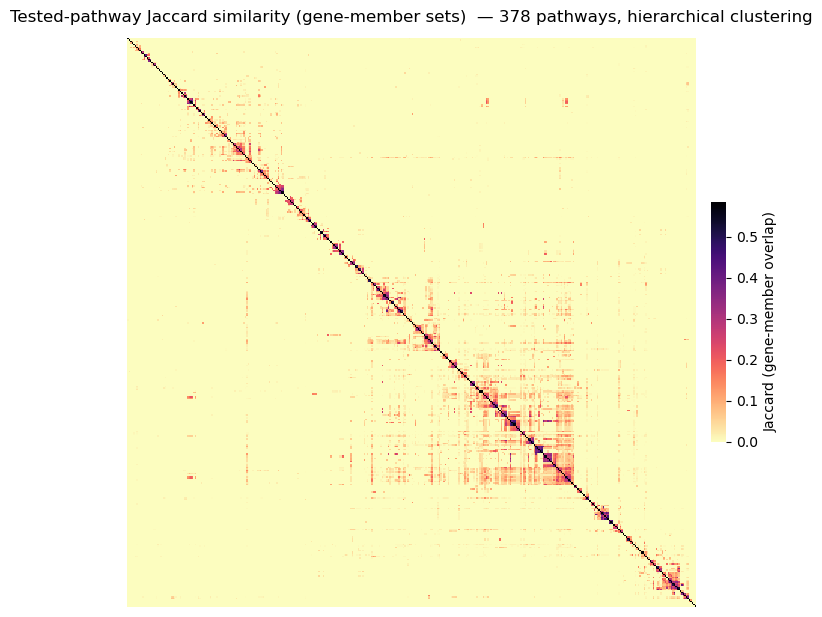

In [13]:
JACC_PARQUET = Path('/home/beraslan/Projects/ChemoGeneticScreens/PathwayORA/KEGG/pathway_jaccard_all_kegg.parquet')

jacc_all = pd.read_parquet(JACC_PARQUET)
in_jacc = [p for p in complete if p in jacc_all.index]
missing = [p for p in complete if p not in jacc_all.index]
print(f'Pathways tested:        {len(complete)}')
print(f'Pathways in Jaccard ref: {len(in_jacc)}')
if missing:
    print(f'  not found in reference  ({len(missing)}): '
          f'{missing[:5]}{"..." if len(missing) > 5 else ""}')

jacc = jacc_all.loc[in_jacc, in_jacc]

# Precompute linkage on the proper Jaccard distance (1 - similarity).
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage as _linkage

dist = 1.0 - jacc.values.astype(float)
np.fill_diagonal(dist, 0)
condensed = squareform(dist, checks=False)
link = _linkage(condensed, method='average')

cg = sns.clustermap(
    jacc,
    cmap='magma_r',
    vmin=0, vmax=jacc.values[~np.eye(len(jacc), dtype=bool)].max(),
    figsize=(6,
              6),
    row_linkage=link,
    col_linkage=link,
    xticklabels=False,
    yticklabels=False,
    cbar_kws={'label': 'Jaccard (gene-member overlap)'},
    dendrogram_ratio=(0.001, 0.001),
    cbar_pos=(1, 0.30, 0.025, 0.40),    # right-side colorbar
)

# Hide both dendrograms (rows/cols still in cluster order)
cg.ax_row_dendrogram.set_visible(False)
cg.ax_col_dendrogram.set_visible(False)

cg.figure.suptitle(
    f'Tested-pathway Jaccard similarity (gene-member sets)  '
    f'— {len(jacc)} pathways, hierarchical clustering',
    y=1.02,
)
out = output_fig.parent / 'tested_pathway_jaccard_clustermap.png'
out.parent.mkdir(parents=True, exist_ok=True)
cg.savefig(out, dpi=120, bbox_inches='tight')
print(f'Wrote {out}')

# Save the row/col order so downstream cells can reuse it if desired.
pathway_jaccard_order = jacc.index[cg.dendrogram_row.reordered_ind].tolist()


### 3. Load OLS results into a long DataFrame

In [14]:
long_df = load_ols_long(input_dir, groups, complete)
long_df.head()

  loaded 2,000/16,632 CSVs (6s)
  loaded 4,000/16,632 CSVs (11s)
  loaded 6,000/16,632 CSVs (17s)
  loaded 8,000/16,632 CSVs (22s)
  loaded 10,000/16,632 CSVs (28s)
  loaded 12,000/16,632 CSVs (33s)
  loaded 14,000/16,632 CSVs (39s)
  loaded 16,000/16,632 CSVs (44s)
  loaded 16,632/16,632 CSVs in 48s (13,142,304 rows total)


,term_type,drug,target_gene,covariate,beta,se,tvalue,pvalue,n_cells,group,batch,pathway
0,target_gene,NaN,ADNP,NaN,-0.003117,0.015954,-0.195401,8.450793e-01,131,group_00,batch1,KEGG_ABC_TRANSPORTERS
1,target_gene,NaN,ADNP2,NaN,0.030808,0.004055,7.596610,3.043552e-14,1541,group_00,batch1,KEGG_ABC_TRANSPORTERS
2,target_gene,NaN,AKR1B1,NaN,0.004470,0.001989,2.247958,2.457914e-02,9502,group_00,batch1,KEGG_ABC_TRANSPORTERS
3,target_gene,NaN,AKT1,NaN,0.001999,0.002898,0.689725,4.903676e-01,4029,group_00,batch1,KEGG_ABC_TRANSPORTERS
4,target_gene,NaN,ATF1,NaN,-0.001584,0.001816,-0.872572,3.828968e-01,10218,group_00,batch1,KEGG_ABC_TRANSPORTERS


### 4. Pivot to pert × (drug, pathway) tensors

In [15]:
beta, pval = build_tensors(long_df)
print(f'beta tensor shape: {beta.shape}  (perts × (drug, pathway))')

Long combined rows: 13,142,304
  drugs: 16  perts: 2173  pathways: 378
beta tensor shape: (2173, 6048)  (perts × (drug, pathway))


### 5. DMSO batch-replicate concordance of base-level effects

Sanity check: the `target_gene` main effects from batch1 and batch2 are
estimated from independent cells (separate libraries) but on the same
biological perturbations and pathways, so they should correlate
strongly if the perturbation × pathway signal is real. Each point in
the scatter is one (perturbation, pathway): `β_DMSO_round2` on the
x-axis, `β_DMSO_round2_batch2` on the y-axis. Pearson and Spearman
correlations and the y = x line are overlaid.


(pert × pathway) cells with both DMSO replicates fit: 821,394
Pearson  r = 0.620
Spearman ρ = 0.424
  significant in both replicates  : 52,348
  significant in DMSO_round2 only   : 41,565
  significant in DMSO_round2_batch2 only   : 40,661
  significant in neither          : 686,820
Wrote /home/beraslan/Projects/ChemoGeneticScreens/PertPathwayDrugInteraction/figures/dmso_replicate_beta_scatter.png


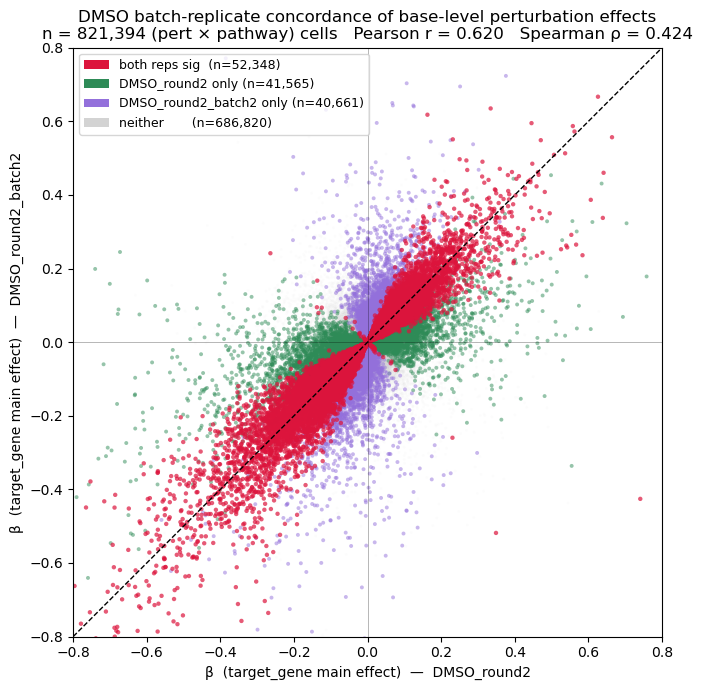

In [16]:
from scipy.stats import pearsonr, spearmanr
from matplotlib.patches import Patch

# Pull the two DMSO target_gene-main-effect slices from the beta and pval tensors.
DMSO_B1 = 'DMSO_round2'
DMSO_B2 = 'DMSO_round2_batch2'
b1 = beta.xs(DMSO_B1, level='drug', axis=1)
b2 = beta.xs(DMSO_B2, level='drug', axis=1)
p1 = pval.xs(DMSO_B1, level='drug', axis=1)
p2 = pval.xs(DMSO_B2, level='drug', axis=1)

common_perts = b1.index.intersection(b2.index)
common_paths = b1.columns.intersection(b2.columns)
b1 = b1.loc[common_perts, common_paths]
b2 = b2.loc[common_perts, common_paths]
p1 = p1.loc[common_perts, common_paths]
p2 = p2.loc[common_perts, common_paths]

x = b1.values.ravel()
y = b2.values.ravel()
pv1 = p1.values.ravel()
pv2 = p2.values.ravel()
mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(pv1) & np.isfinite(pv2)
x = x[mask]; y = y[mask]; pv1 = pv1[mask]; pv2 = pv2[mask]
print(f'(pert × pathway) cells with both DMSO replicates fit: {len(x):,}')

r_pear, _ = pearsonr(x, y)
r_spear, _ = spearmanr(x, y)
print(f'Pearson  r = {r_pear:.3f}')
print(f'Spearman ρ = {r_spear:.3f}')

# Significance categories (p_threshold from Section parameters)
sig1 = pv1 < p_threshold
sig2 = pv2 < p_threshold
both    =  sig1 &  sig2
only_1  =  sig1 & ~sig2
only_2  = ~sig1 &  sig2
neither = ~sig1 & ~sig2

n_both    = int(both.sum())
n_only_1  = int(only_1.sum())
n_only_2  = int(only_2.sum())
n_neither = int(neither.sum())
print(f'  significant in both replicates  : {n_both:,}')
print(f'  significant in {DMSO_B1} only   : {n_only_1:,}')
print(f'  significant in {DMSO_B2} only   : {n_only_2:,}')
print(f'  significant in neither          : {n_neither:,}')

fig, ax = plt.subplots(figsize=(7, 7))

# Plot in order: faintest → most prominent so the few "both"-significant
# points end up on top.
ax.scatter(x[neither], y[neither],
           s=4, alpha=0.05, color='lightgrey',
           edgecolor='none', label=f'neither (n={n_neither:,})')
ax.scatter(x[only_1],  y[only_1],
           s=8, alpha=0.5, color='seagreen',
           edgecolor='none', label=f'{DMSO_B1} only (n={n_only_1:,})')
ax.scatter(x[only_2],  y[only_2],
           s=8, alpha=0.5, color='mediumpurple',
           edgecolor='none', label=f'{DMSO_B2} only (n={n_only_2:,})')
ax.scatter(x[both],    y[both],
           s=10, alpha=0.7, color='crimson',
           edgecolor='none', label=f'both (n={n_both:,})')

# y = x reference and zero lines
lim = 0.8
ax.plot([-lim, lim], [-lim, lim], color='black', linewidth=1, linestyle='--', label='y = x')
ax.axhline(0, color='black', linewidth=0.5, alpha=0.4)
ax.axvline(0, color='black', linewidth=0.5, alpha=0.4)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_aspect('equal', adjustable='box')

ax.set_xlabel(f'β  (target_gene main effect)  —  {DMSO_B1}')
ax.set_ylabel(f'β  (target_gene main effect)  —  {DMSO_B2}')
ax.set_title(
    f'DMSO batch-replicate concordance of base-level perturbation effects\n'
    f'n = {len(x):,} (pert × pathway) cells   '
    f'Pearson r = {r_pear:.3f}   Spearman ρ = {r_spear:.3f}'
)

# Legend handles with full alpha so colors read clearly
ax.legend(
    handles=[
        Patch(facecolor='crimson',      label=f'both reps sig  (n={n_both:,})'),
        Patch(facecolor='seagreen',     label=f'{DMSO_B1} only (n={n_only_1:,})'),
        Patch(facecolor='mediumpurple', label=f'{DMSO_B2} only (n={n_only_2:,})'),
        Patch(facecolor='lightgrey',    label=f'neither       (n={n_neither:,})'),
    ],
    loc='upper left', fontsize=9, frameon=True,
)
fig.tight_layout()

out = output_fig.parent / 'dmso_replicate_beta_scatter.png'
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=150, bbox_inches='tight')
print(f'Wrote {out}')
plt.show()


### 6. Convert β + p-value to sign-significance matrix

In [17]:
sig = to_sign_sig(beta, pval, p_threshold)
sig.head()

drug                   AR-A014418                              \
pathway     KEGG_ABC_TRANSPORTERS KEGG_ACUTE_MYELOID_LEUKEMIA   
target_gene                                                     
A1BG                            0                           0   
AASS                            0                           0   
ABCB6                           0                           0   
ABCC5                           0                           0   
ABCF1                           0                           0   

drug                                                                     \
pathway     KEGG_ADHERENS_JUNCTION KEGG_ADIPOCYTOKINE_SIGNALING_PATHWAY   
target_gene                                                               
A1BG                             0                                    0   
AASS                             0                                    0   
ABCB6                            0                                    0   
ABCC5                            0                                    0   
ABCF1                            0                                    0   

drug                                                         \
pathway     KEGG_ALANINE_ASPARTATE_AND_GLUTAMATE_METABOLISM   
target_gene                                                   
A1BG                                                      0   
AASS                                                      0   
ABCB6                                                     0   
ABCC5                                                     0   
ABCF1                                                     0   

drug                                                        \
pathway     KEGG_ALDOSTERONE_REGULATED_SODIUM_REABSORPTION   
target_gene                                                  
A1BG                                                     0   
AASS                                                     0   
ABCB6                                                    0   
ABCC5                                                    0   
ABCF1                                                    0   

drug                                                                      \
pathway     KEGG_ALPHA_LINOLENIC_ACID_METABOLISM KEGG_ALZHEIMERS_DISEASE   
target_gene                                                                
A1BG                                           0                       0   
AASS                                           0                       0   
ABCB6                                         -1                       0   
ABCC5                                          0                       0   
ABCF1                                          0                       0   

drug                                          \
pathway     KEGG_AMINOACYL_TRNA_BIOSYNTHESIS   
target_gene                                    
A1BG                                       0   
AASS                                       0   
ABCB6                                      0   
ABCC5                                      0   
ABCF1                                      0   

drug                                                          ...  \
pathway     KEGG_AMINO_SUGAR_AND_NUCLEOTIDE_SUGAR_METABOLISM  ...   
target_gene                                                   ...   
A1BG                                                       0  ...   
AASS                                                       0  ...   
ABCB6                                                      0  ...   
ABCC5                                                      0  ...   
ABCF1                                                      0  ...   

drug                                           VX-11e  \
pathway     KEGG_TOLL_LIKE_RECEPTOR_SIGNALING_PATHWAY   
target_gene                                             
A1BG                                                0   
AASS                                                0   
ABCB6                                       

In [18]:
beta.shape

(2173, 6048)

### 7. Diagnostic histograms

Five views of the OLS interaction-term significance pattern, before any
pert/pathway filtering for the main heatmap:

1. **Per-perturbation total**: how many `drug:target_gene` interaction
   terms are significant for each perturbation, summed across all
   non-DMSO drugs and all pathways.
2. **Per-drug, per-pert (pathway counts)**: how many pathways are
   significant for each perturbation within each drug context. One
   panel per non-DMSO drug.
3. **Per-drug, per-pathway (pert counts) — transpose of #2**: how many
   perturbations are significant for each pathway within each drug
   context. One panel per non-DMSO drug.
4. **Cross-drug consistency clustermap**: rows are perturbations,
   columns are pathways, and each cell is the number of non-DMSO drug
   contexts in which that (pert, pathway) interaction is significant.
   Rows filtered to perts with a significant interaction in ≥ 10
   pathways; columns filtered by col_sum > 10. Hierarchical clustering
   with dendrograms is rendered on both axes.
5. **Per-drug sign-significance, same order as #4**: a panel per
   non-DMSO drug showing the (pert × pathway) sign-significance matrix
   (+1 / 0 / −1) using the same row and column ordering produced by the
   clustermap in #4.


Wrote /home/beraslan/Projects/ChemoGeneticScreens/PertPathwayDrugInteraction/figures/diagnostic_sig_interactions_per_pert.png
  perturbations: 2173
  total sig interactions:  median=135  mean=226.8  max=1867  zero=0/2173
  positive sig: median=70  mean=116.3  max=895
  negative sig: median=67  mean=110.5  max=1143
Wrote /home/beraslan/Projects/ChemoGeneticScreens/PertPathwayDrugInteraction/figures/diagnostic_sig_pathways_per_pert_by_drug.png

Per-drug summary:
                       n_perts_with_any_sig  median_sig_paths_per_pert  mean_sig_paths_per_pert  max_sig_paths_in_any_pert
CHIR-98014                             2173                       19.0                36.169811                        254
LY2090314                              2167                       17.0                33.554993                        252
VX-11e                                 2162                       12.0                23.420156                        241
LDN-193189                             2158

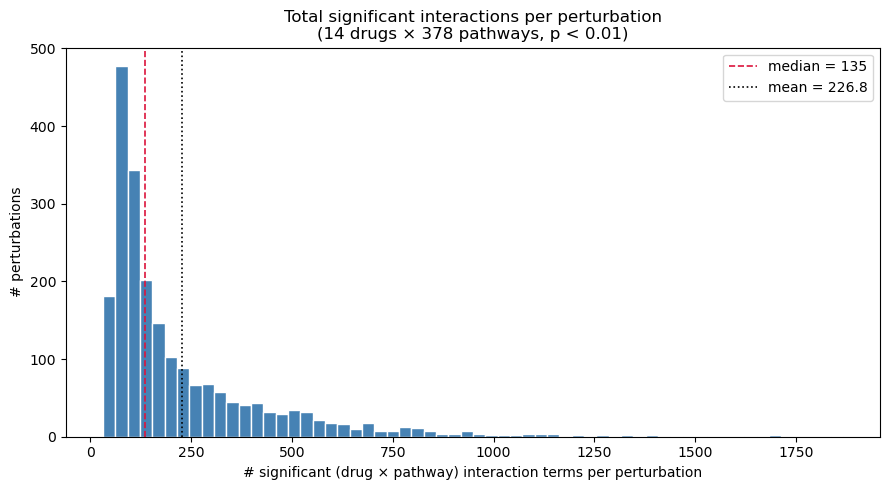

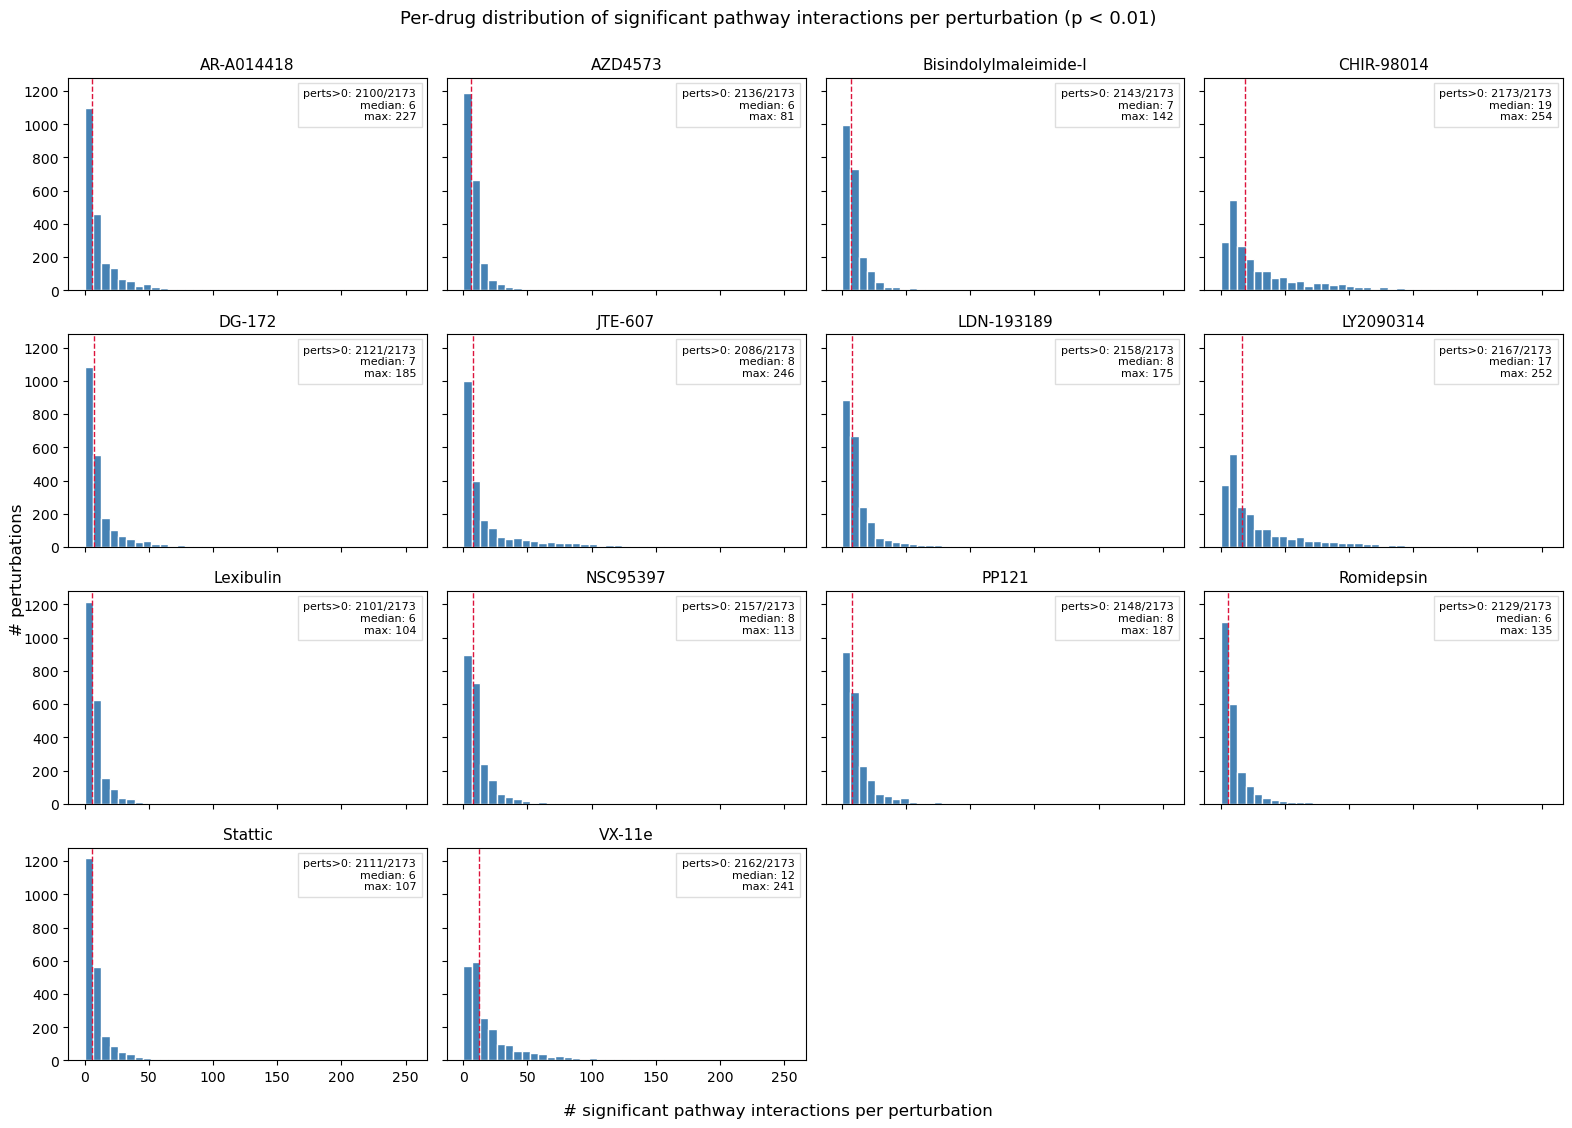

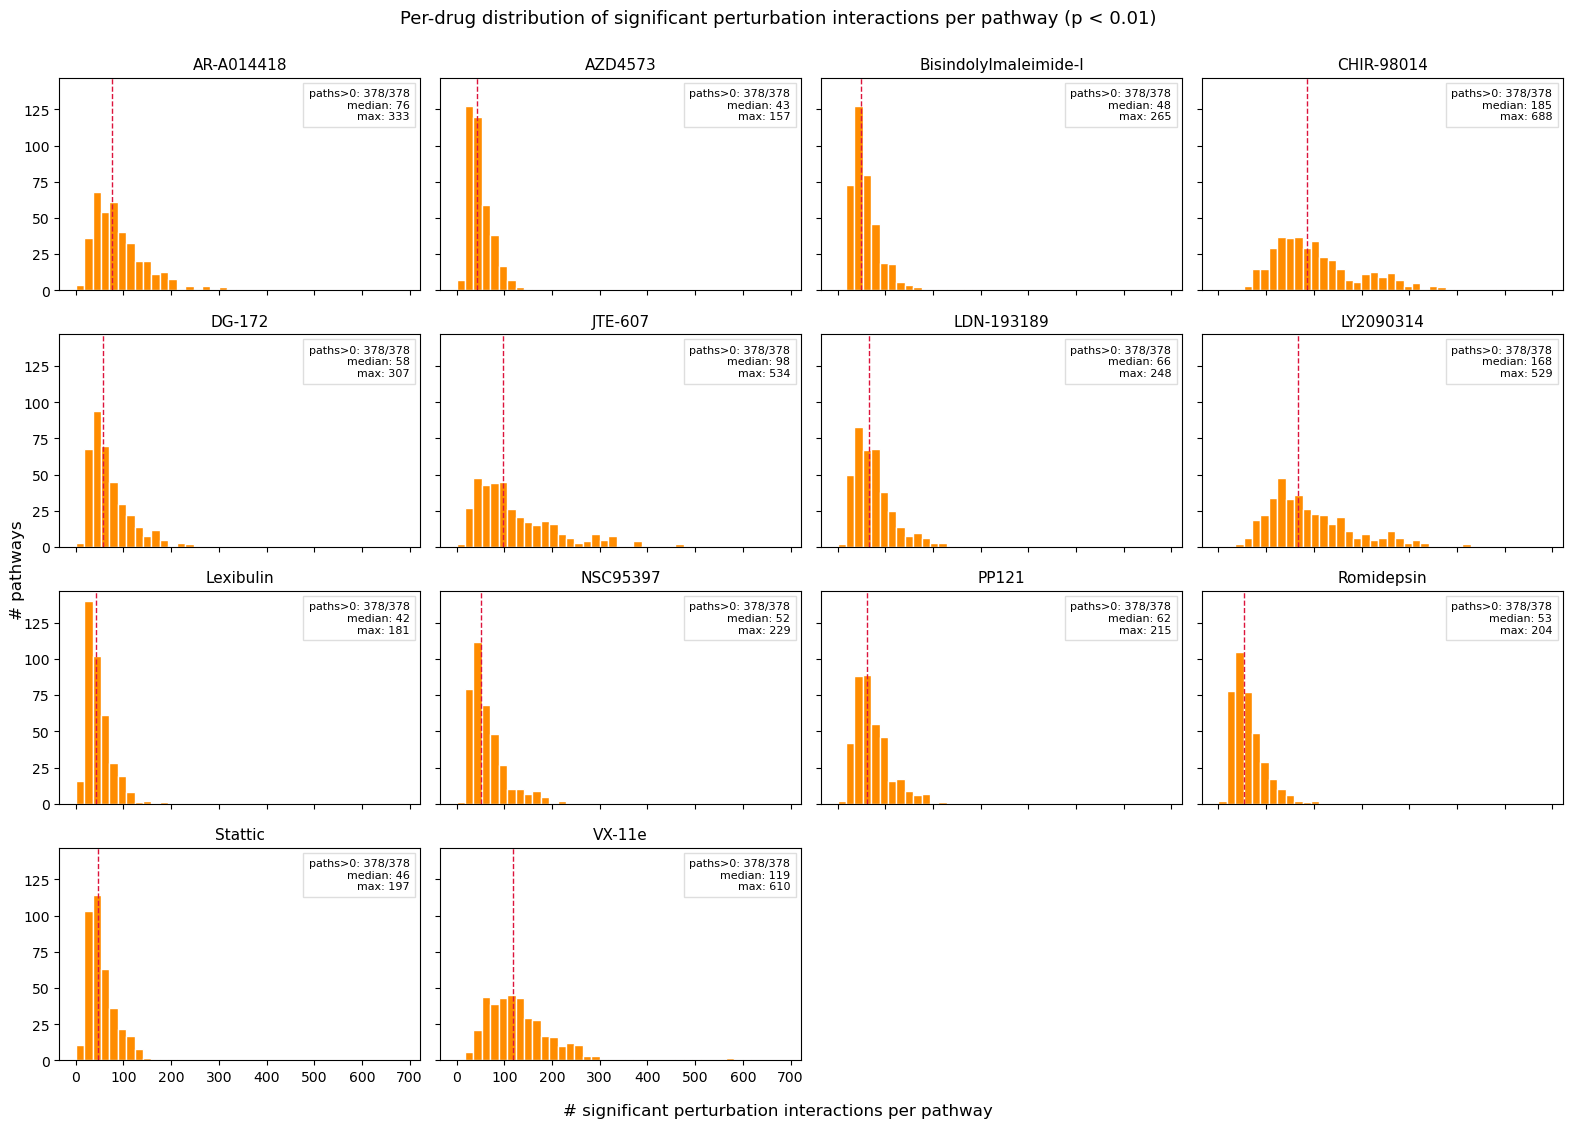

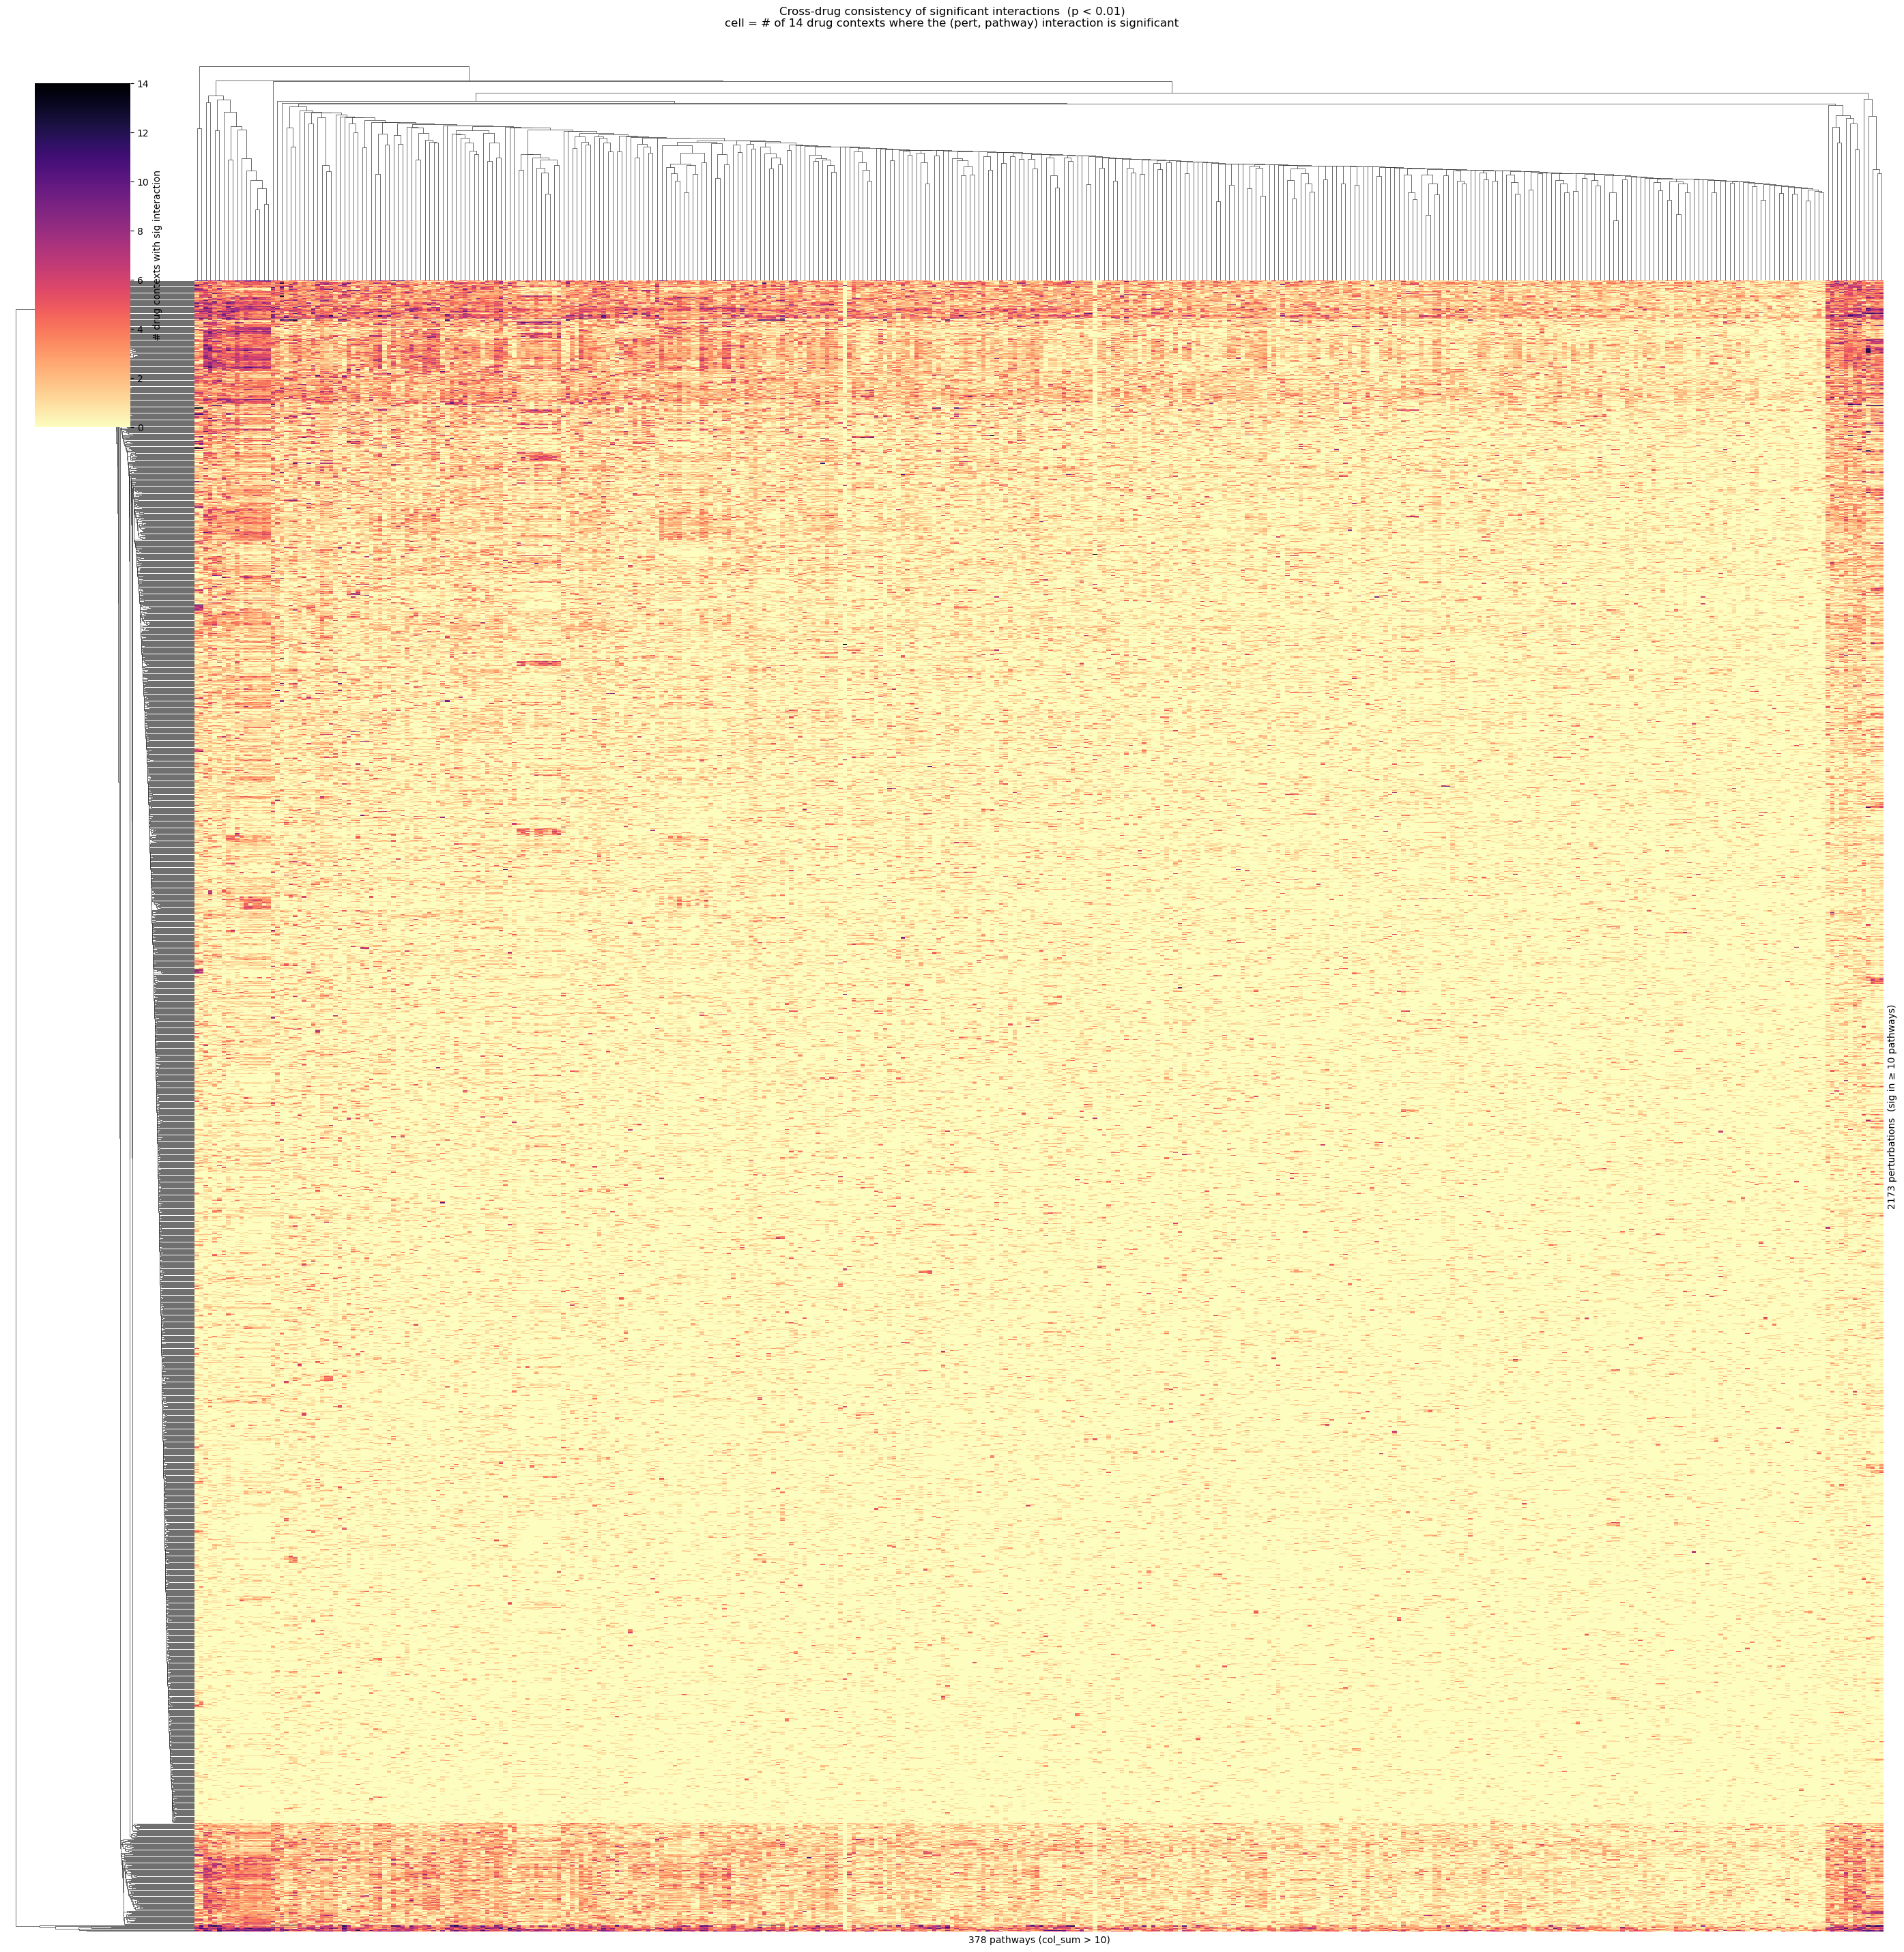

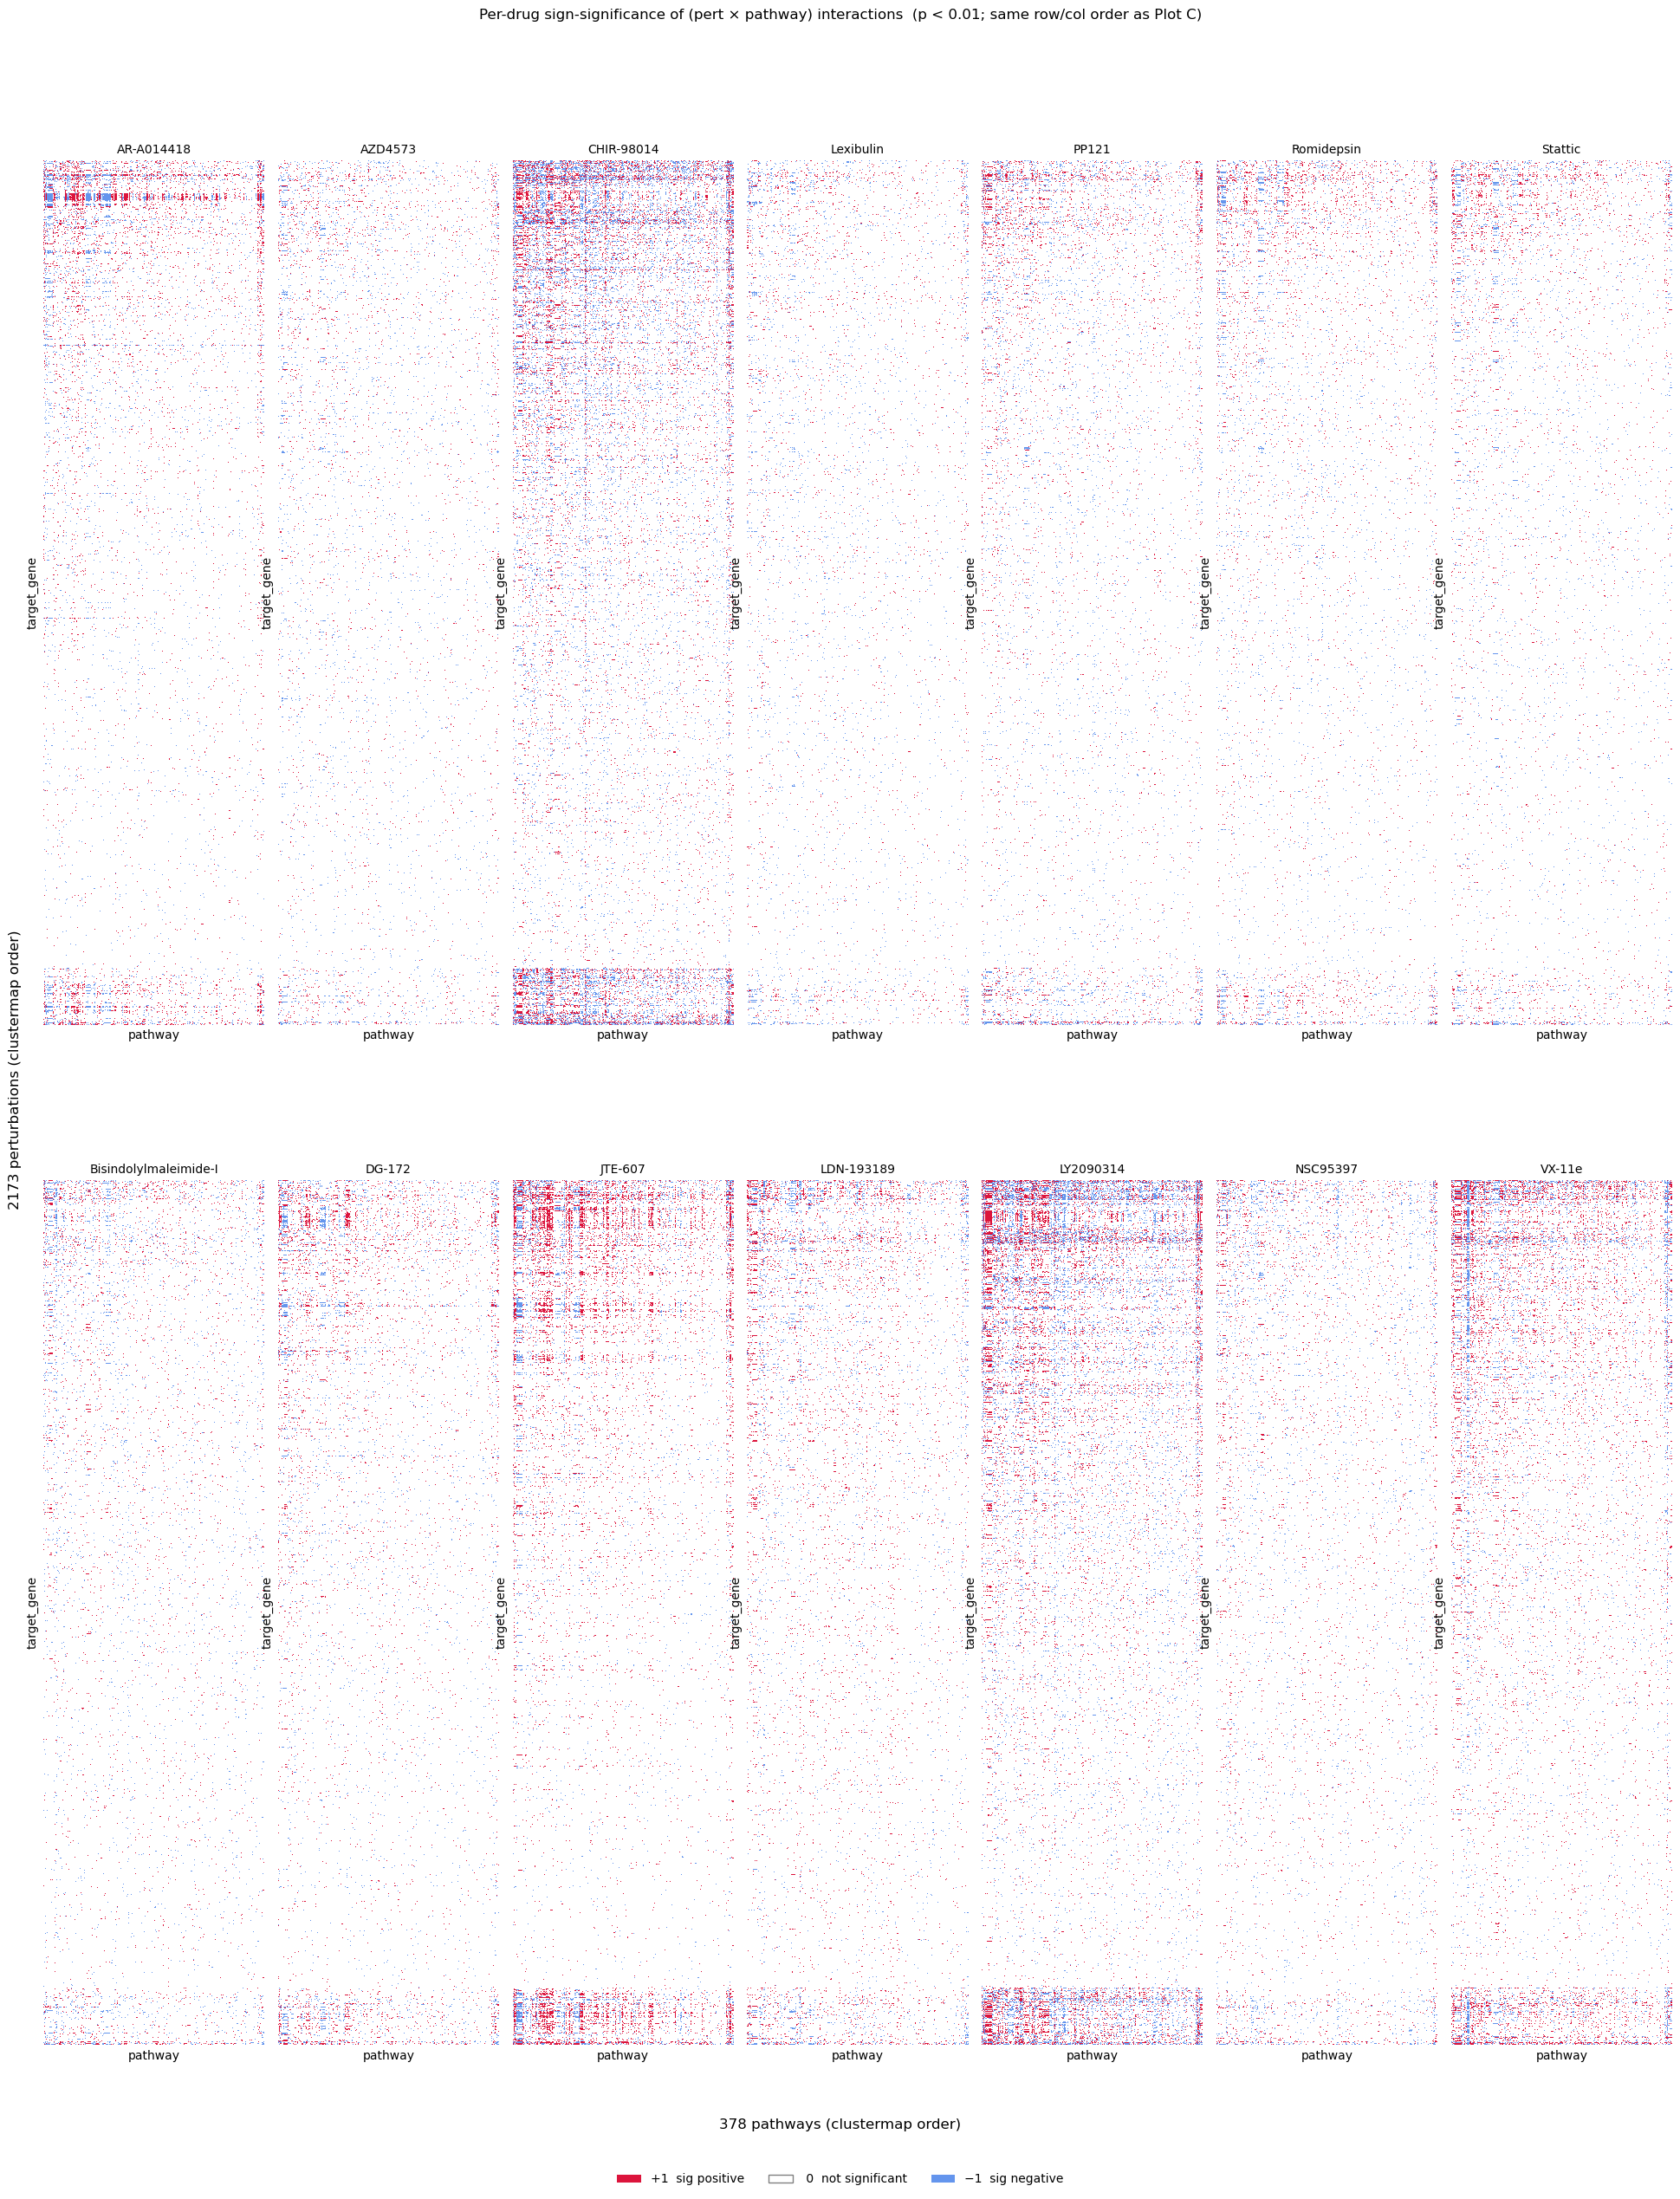

In [19]:
diag_dir = output_fig.parent
(fig_a, fig_b, fig_bp, drug_summary, drug_summary_paths,
 drug_context_heatmap, per_drug_signsig) = plot_diagnostic_histograms(
    sig, p_threshold=p_threshold, output_dir=diag_dir,
    pert_min_paths_with_sig=10,   # rows: pert sig in ≥ 10 pathways
    path_col_min=10,               # cols: pathway col_sum > 10
)


### 8. Filter perts and pathways by significance counts

In [20]:
keep_perts, keep_paths = filter_perts_pathways(sig, pert_min_sig, path_min_sig)

Perts kept: 1431 / 2173 (min sig interactions per pert ≥ 100)
Pathways kept: 378 / 378 (min sig tests per pathway ≥ 20)


### 9. Plot the 2 × 8 grid (and save tensors)

Reuses the perturbation and pathway ordering from the Section 7
clustermap (`drug_context_heatmap.index` and `.columns`). Any perts /
pathways that pass the Section 8 filter but were not present in the
clustermap (because they failed its more lenient thresholds) are
appended at the end, separately clustered.


Pert order: 1431 from clustermap reference + 0 appended (clustered on leftover subset)
Pathway order: 378 from clustermap reference + 0 appended (clustered on leftover subset)
Wrote /home/beraslan/Projects/ChemoGeneticScreens/PertPathwayDrugInteraction/figures/pert_pathway_drug_grid.png
Wrote tensors + orderings to /home/beraslan/Projects/ChemoGeneticScreens/PertPathwayDrugInteraction/figures/tensors


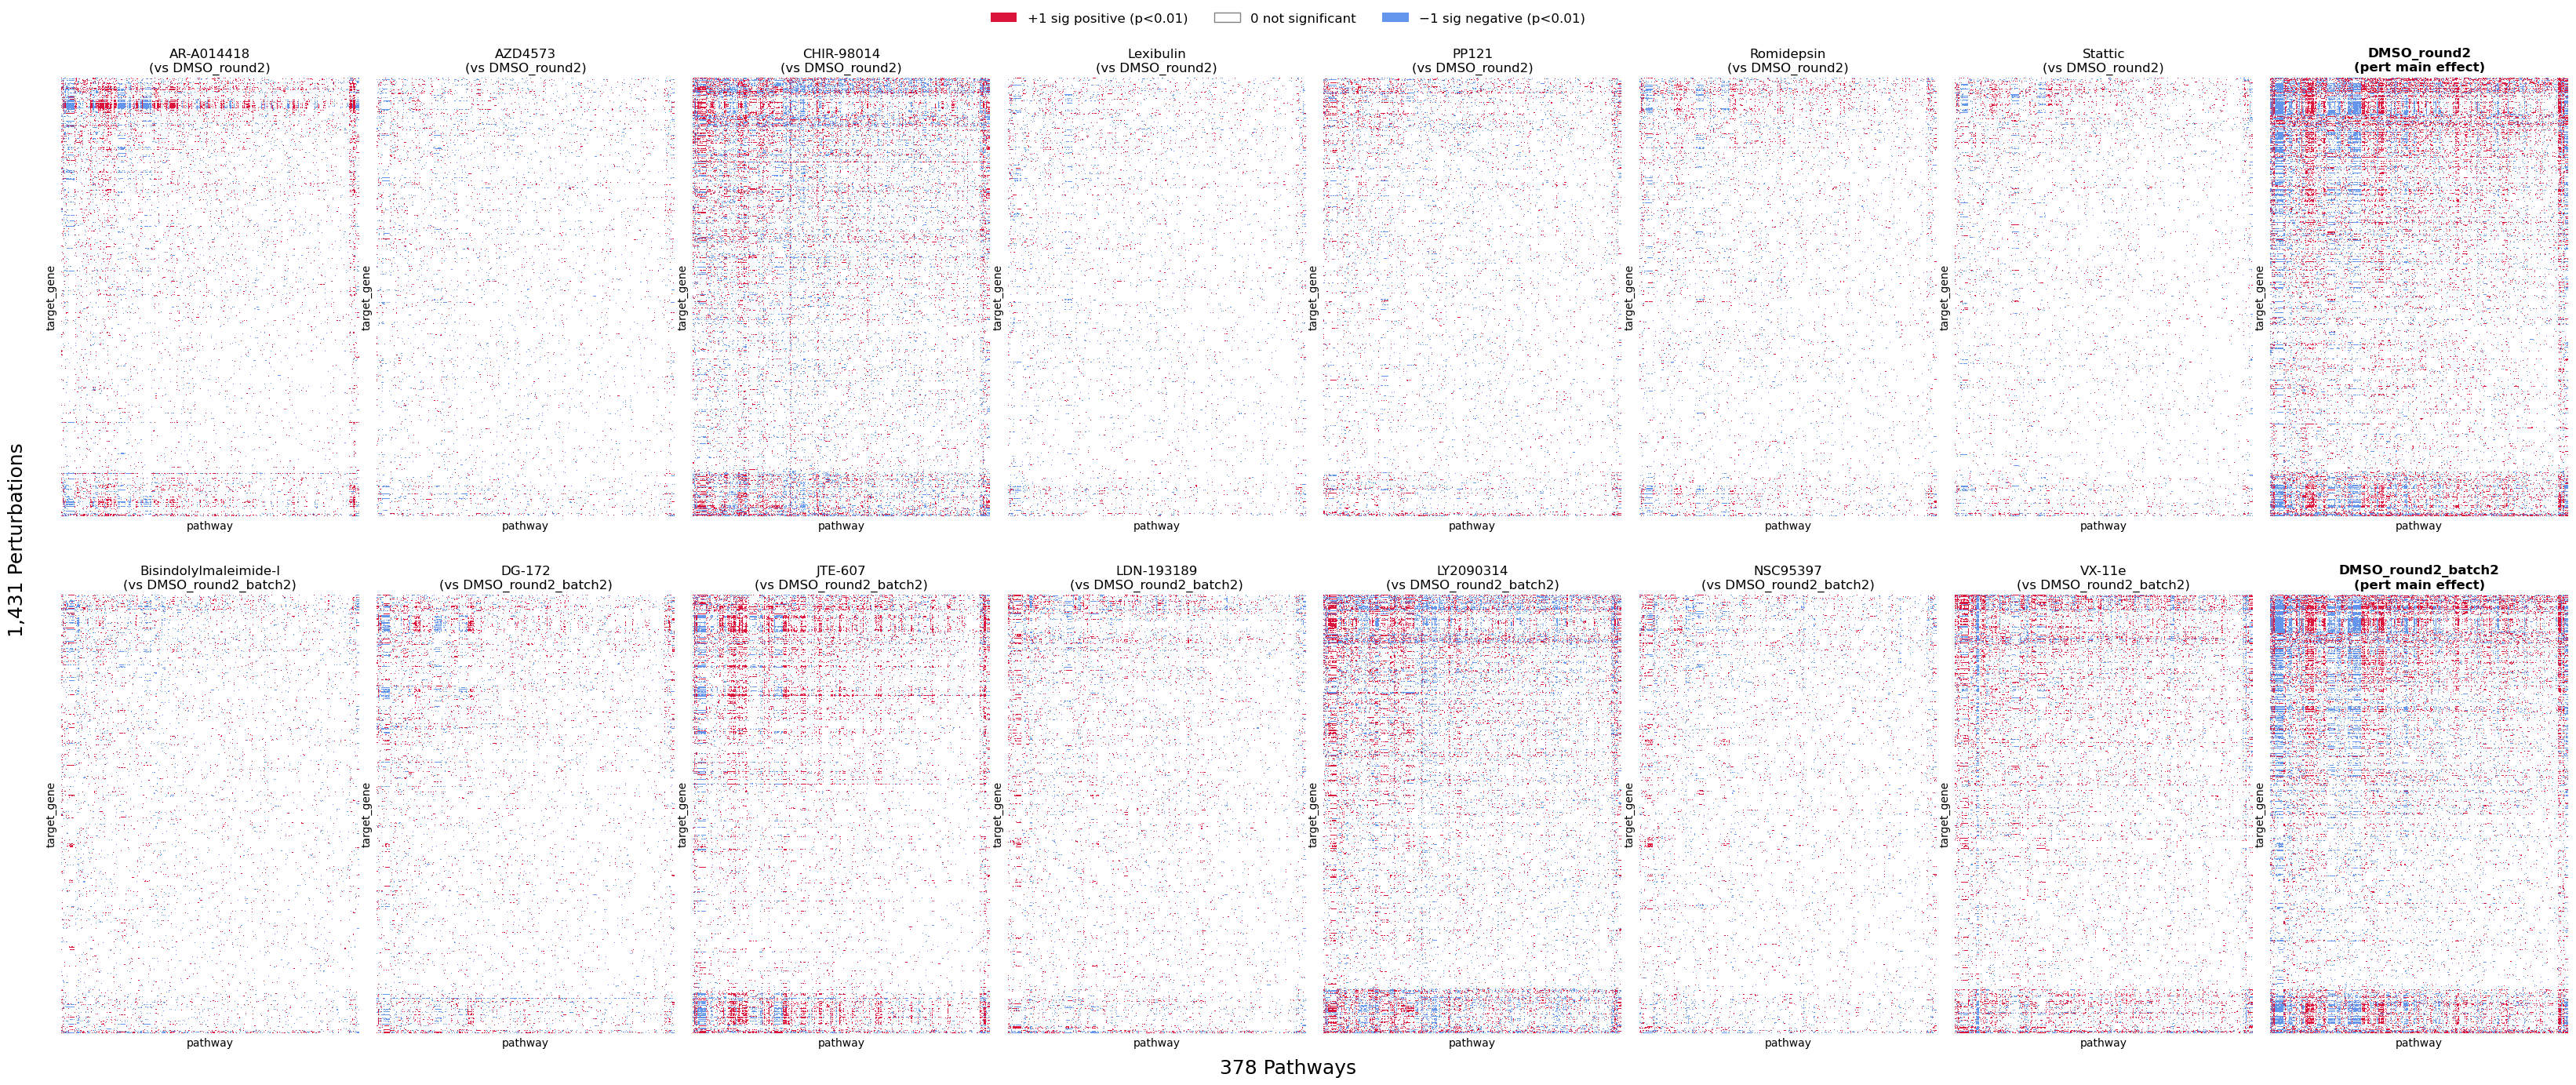

In [21]:
fig, pert_order_main, path_order_main = plot_grid(
    sig, beta, keep_perts, keep_paths, output_fig, p_threshold,
    pert_order_ref=drug_context_heatmap.index.tolist(),
    path_order_ref=drug_context_heatmap.columns.tolist(),
)


### 10. Antagonism vs synergy of drug × perturbation interactions

For every (perturbation $p$, pathway $k$, non-DMSO drug $d$) cell we
compare the sign of the interaction coefficient $\delta_{d,p,k}$ to
the sign of the matching DMSO target-gene main effect
$\beta^{\mathrm{DMSO}_b}_{p,k}$ (with $b$ = drug $d$'s batch). Drug
$d$ is called **synergistic** with the perturbation if both signs
agree (the drug amplifies the perturbation's pathway direction) and
**antagonistic** if they disagree (the drug reverses it). Cells with
non-significant interaction terms ($p \geq$ `p_threshold`) or with an
undefined DMSO base-level sign are coloured white.

The figure mirrors the Section 9 grid: one panel per non-DMSO drug,
**same perturbation × pathway ordering** as the Section 7 cross-drug
consistency clustermap. Cells: red = synergy, blue = antagonism,
white = not classified.


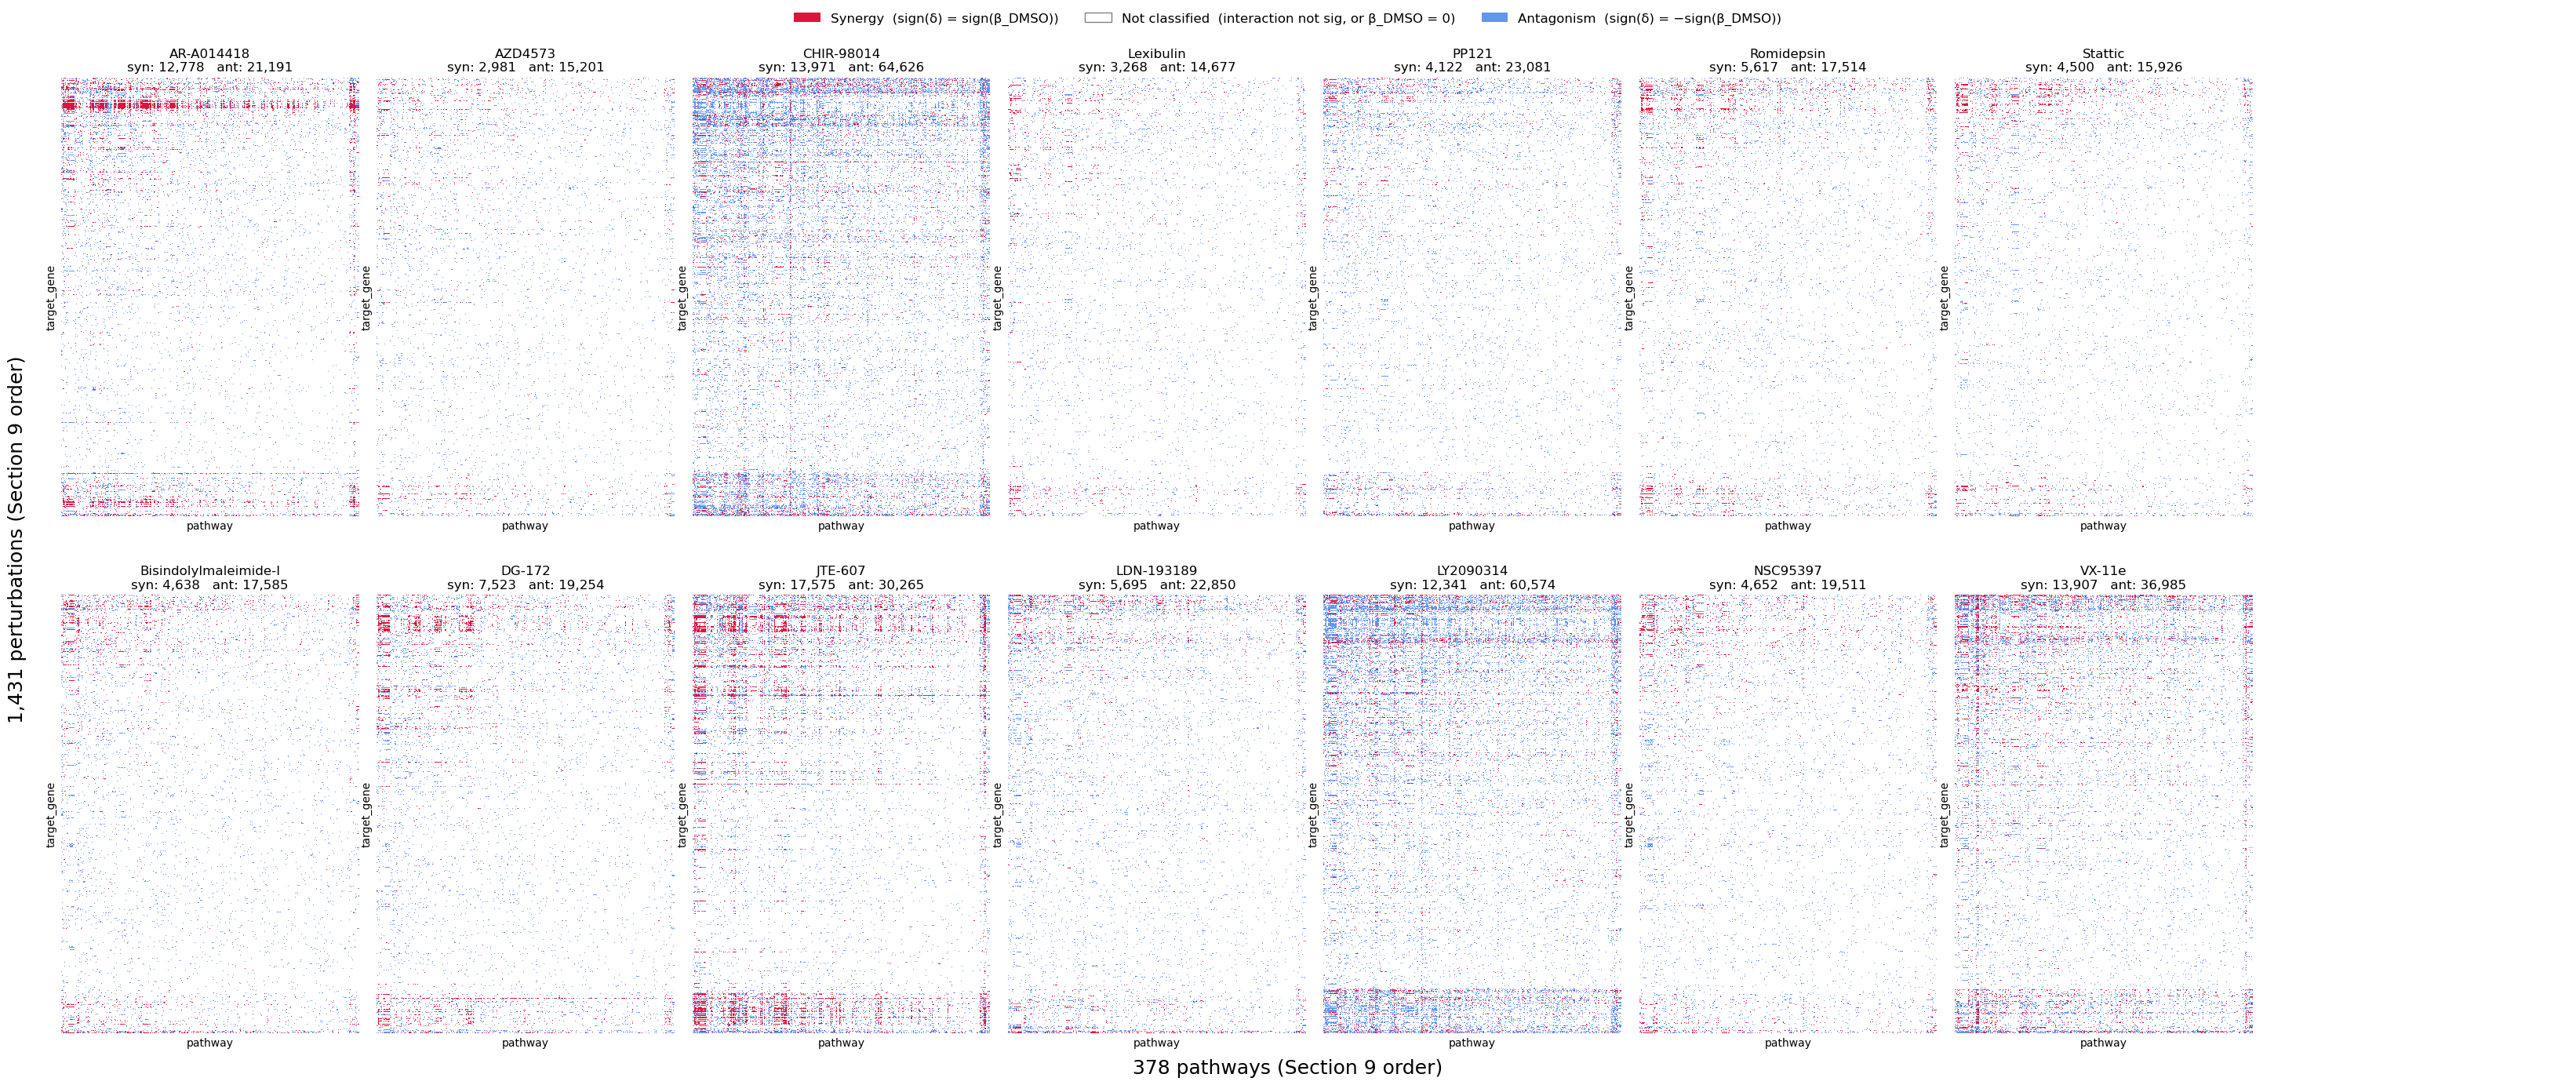


Per-drug synergy / antagonism counts (over the Section 9 filtered grid):
  AR-A014418                syn=12,778  ant=21,191  syn/(syn+ant)=0.38
  AZD4573                   syn= 2,981  ant=15,201  syn/(syn+ant)=0.16
  CHIR-98014                syn=13,971  ant=64,626  syn/(syn+ant)=0.18
  Lexibulin                 syn= 3,268  ant=14,677  syn/(syn+ant)=0.18
  PP121                     syn= 4,122  ant=23,081  syn/(syn+ant)=0.15
  Romidepsin                syn= 5,617  ant=17,514  syn/(syn+ant)=0.24
  Stattic                   syn= 4,500  ant=15,926  syn/(syn+ant)=0.22
  Bisindolylmaleimide-I     syn= 4,638  ant=17,585  syn/(syn+ant)=0.21
  DG-172                    syn= 7,523  ant=19,254  syn/(syn+ant)=0.28
  JTE-607                   syn=17,575  ant=30,265  syn/(syn+ant)=0.37
  LDN-193189                syn= 5,695  ant=22,850  syn/(syn+ant)=0.20
  LY2090314                 syn=12,341  ant=60,574  syn/(syn+ant)=0.17
  NSC95397                  syn= 4,652  ant=19,511  syn/(syn+ant)=0.19
  V

In [22]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

SYN_CMAP = ListedColormap(['cornflowerblue', 'white', 'crimson'])

# Reuse the EXACT row/column order produced by Section 9 plot_grid
# (which itself reuses the Section 7 clustermap order, then appends any
# leftover perts/pathways clustered separately).
pert_order = pert_order_main
path_order = path_order_main

# Restrict synergy classification to the same filtered set used by plot_grid
keep_perts_set = set(pert_order)
keep_paths_set = set(path_order)

# Per-batch DMSO main-effect signs
dmso_main_sign = {}
for batch in ('batch1', 'batch2'):
    dmso_drug = DMSO_OF_BATCH[batch]
    dmso_main_sign[batch] = (
        np.sign(beta.xs(dmso_drug, level='drug', axis=1).fillna(0).values)
        .astype(np.int8)
    )

# Compute synergy code (-1 / 0 / +1) per non-DMSO drug
synergy = {}
for batch in ('batch1', 'batch2'):
    dmso_drug = DMSO_OF_BATCH[batch]
    dmso_main = beta.xs(dmso_drug, level='drug', axis=1)
    dsign = dmso_main_sign[batch]
    for d in BATCH_DRUGS[batch]:
        if d == dmso_drug:
            continue
        try:
            delta_df = beta.xs(d, level='drug', axis=1)
            sig_df   = sig.xs(d, level='drug', axis=1)
        except KeyError:
            continue
        delta_sign = np.sign(delta_df.fillna(0).values).astype(np.int8)
        is_sig     = (sig_df.values != 0).astype(np.int8)
        defined    = (dsign != 0).astype(np.int8)
        same       = (delta_sign == dsign).astype(np.int8)
        opp        = (delta_sign == -dsign).astype(np.int8)
        # +1 synergy, -1 antagonism, 0 not classified
        code = is_sig * defined * (same - opp)
        synergy[d] = pd.DataFrame(code,
                                  index=delta_df.index,
                                  columns=delta_df.columns)

counts_syn = {d: int((m.values ==  1).sum()) for d, m in synergy.items()}
counts_ant = {d: int((m.values == -1).sum()) for d, m in synergy.items()}

# 2 × 8 figure mirroring Section 9 plot_grid (figsize=(34, 14)). The 8th
# column is left blank in each row since synergy/antagonism is meaningful
# only for the 7 non-DMSO drugs per batch.
fig, axes = plt.subplots(2, 8, figsize=(34, 14))
fig.subplots_adjust(left=0.04, right=0.98, top=0.92, bottom=0.05,
                     wspace=0.06, hspace=0.18)

for row_i, batch in enumerate(['batch1', 'batch2']):
    drugs_b = [d for d in BATCH_DRUGS[batch] if d != DMSO_OF_BATCH[batch]]
    for col_i, drug in enumerate(drugs_b):
        ax = axes[row_i, col_i]
        if drug not in synergy:
            ax.set_axis_off()
            continue
        sub = synergy[drug].reindex(index=pert_order, columns=path_order)
        sns.heatmap(sub, ax=ax, cmap=SYN_CMAP, vmin=-1, vmax=1, center=0,
                     cbar=False, xticklabels=False, yticklabels=False)
        ax.set_title(
            f'{drug}\n'
            f'syn: {counts_syn[drug]:,}   ant: {counts_ant[drug]:,}',
            fontsize=12,
        )
    # Last column (col 7) - hide
    axes[row_i, 7].set_axis_off()

fig.supxlabel(f'{len(path_order):,} pathways (Section 9 order)', fontsize=18)
fig.supylabel(f'{len(pert_order):,} perturbations (Section 9 order)', fontsize=18)
fig.legend(
    handles=[
        Patch(facecolor='crimson',
              label=f'Synergy  (sign(δ) = sign(β_DMSO))'),
        Patch(facecolor='white', edgecolor='gray',
              label='Not classified  (interaction not sig, or β_DMSO = 0)'),
        Patch(facecolor='cornflowerblue',
              label=f'Antagonism  (sign(δ) = −sign(β_DMSO))'),
    ],
    loc='upper center', bbox_to_anchor=(0.5, 0.99),
    ncol=3, fontsize=12, frameon=False,
)

plt.show()

# Per-drug summary
print()
print('Per-drug synergy / antagonism counts (over the Section 9 filtered grid):')
for d in synergy:
    s = counts_syn[d]; a = counts_ant[d]
    print(f'  {d:<25s} syn={s:>6,}  ant={a:>6,}  '
          f'syn/(syn+ant)={s/max(s+a,1):.2f}')


### 11. Top-30 pathways by synergistic / antagonistic interactions

For every (drug, pathway) cell, count how many perturbations show a
**synergistic** interaction (sign of $\delta_{d,p,k}$ matches sign of
$\beta^{\mathrm{DMSO}_b}_{p,k}$, with significant interaction) and
how many show an **antagonistic** one (signs disagree, with
significant interaction). The two heatmaps below show, separately, the
top 30 pathways ranked by total synergistic and total antagonistic
counts across all drug contexts. Rows are drugs, columns are the
ranked pathways.


(drug × pathway) shape: (14, 378)
Top-30 pathways by total synergistic count:  top-1 = KEGG_SPLICEOSOME (1,476 perts)
Top-30 pathways by total antagonistic count:  top-1 = KEGG_STEROID_BIOSYNTHESIS (2,259 perts)


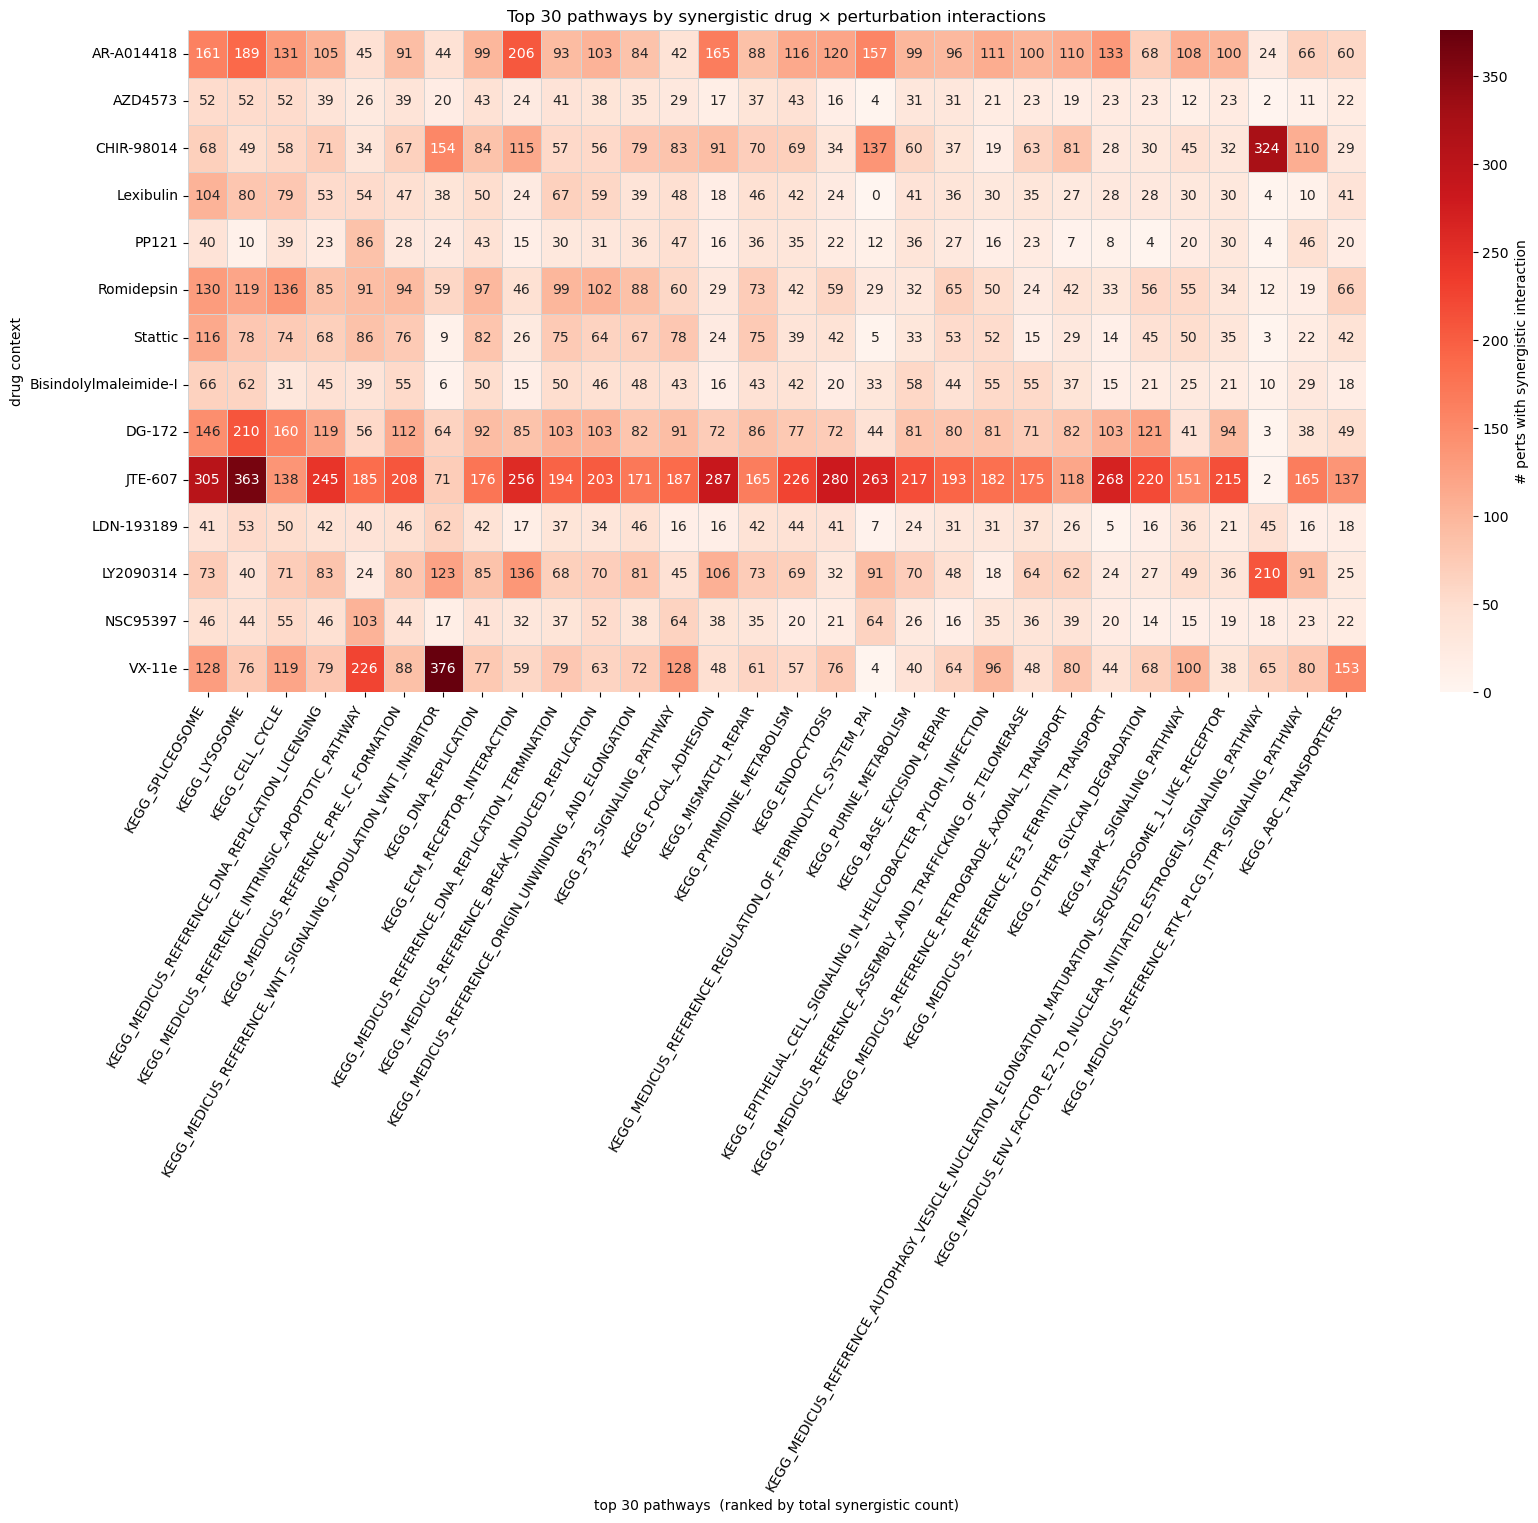

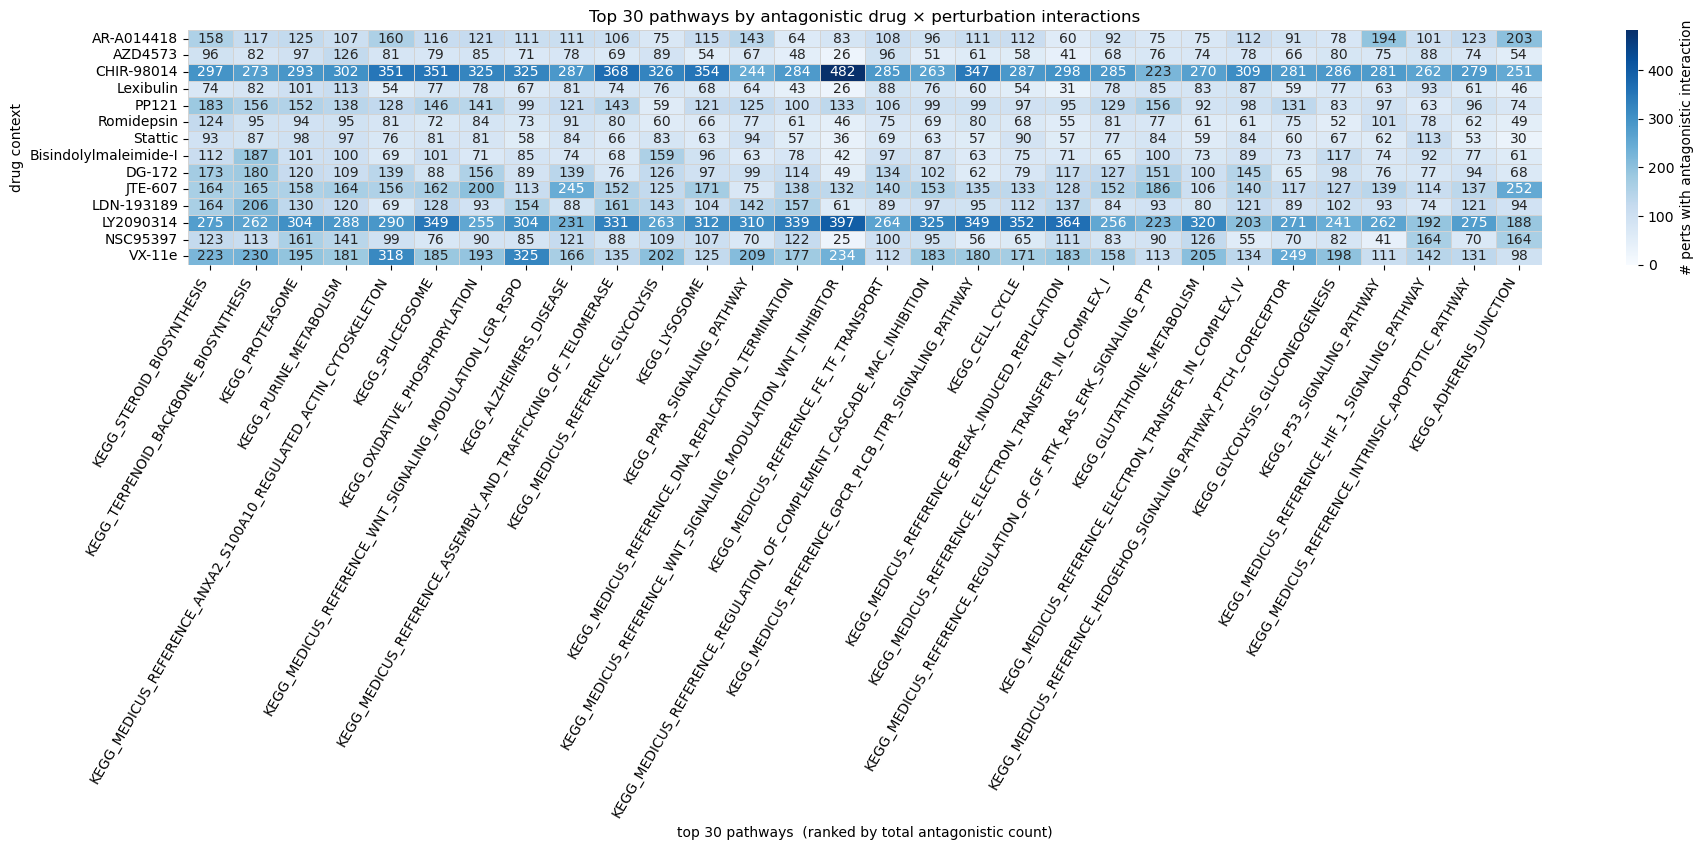


Top 30 synergistic-rich pathways (col-sum):
  KEGG_SPLICEOSOME                                                       1,476
  KEGG_LYSOSOME                                                          1,425
  KEGG_CELL_CYCLE                                                        1,193
  KEGG_MEDICUS_REFERENCE_DNA_REPLICATION_LICENSING                       1,103
  KEGG_MEDICUS_REFERENCE_INTRINSIC_APOPTOTIC_PATHWAY                     1,095
  KEGG_MEDICUS_REFERENCE_PRE_IC_FORMATION                                1,075
  KEGG_MEDICUS_REFERENCE_WNT_SIGNALING_MODULATION_WNT_INHIBITOR          1,067
  KEGG_DNA_REPLICATION                                                   1,061
  KEGG_ECM_RECEPTOR_INTERACTION                                          1,056
  KEGG_MEDICUS_REFERENCE_DNA_REPLICATION_TERMINATION                     1,030
  KEGG_MEDICUS_REFERENCE_BREAK_INDUCED_REPLICATION                       1,024
  KEGG_MEDICUS_REFERENCE_ORIGIN_UNWINDING_AND_ELONGATION                   966
  KEGG_

In [23]:
# Build per-(drug, pathway) counts from the `synergy` dict computed in Section 10
all_drugs_ordered = (
    [d for d in BATCH_DRUGS["batch1"] if d != DMSO_OF_BATCH["batch1"]]
    + [d for d in BATCH_DRUGS["batch2"] if d != DMSO_OF_BATCH["batch2"]]
)
all_drugs_ordered = [d for d in all_drugs_ordered if d in synergy]

# (drug × pathway) counts — count perts with each sign per (drug, pathway)
syn_counts_full = pd.DataFrame(
    {d: (synergy[d] ==  1).sum(axis=0) for d in all_drugs_ordered}
).T  # rows = drugs, cols = pathways
ant_counts_full = pd.DataFrame(
    {d: (synergy[d] == -1).sum(axis=0) for d in all_drugs_ordered}
).T

print(f'(drug × pathway) shape: {syn_counts_full.shape}')

TOP_N = 30
top_syn = syn_counts_full.sum(axis=0).sort_values(ascending=False).head(TOP_N).index
top_ant = ant_counts_full.sum(axis=0).sort_values(ascending=False).head(TOP_N).index

print(f'Top-{TOP_N} pathways by total synergistic count:'
      f'  top-1 = {top_syn[0]} ({syn_counts_full[top_syn[0]].sum():,} perts)')
print(f'Top-{TOP_N} pathways by total antagonistic count:'
      f'  top-1 = {top_ant[0]} ({ant_counts_full[top_ant[0]].sum():,} perts)')

# Order pathways within each top-30 by their column-sum (descending)
syn_top = syn_counts_full.loc[:, top_syn]
ant_top = ant_counts_full.loc[:, top_ant]

# Plot — two stacked figures, one per direction
for label, mat, cmap in [
    ('synergistic',  syn_top, 'Reds'),
    ('antagonistic', ant_top, 'Blues'),
]:
    fig, ax = plt.subplots(figsize=(min(0.5 * mat.shape[1] + 4, 22),
                                      0.4 * mat.shape[0] + 3))
    sns.heatmap(
        mat, ax=ax,
        cmap=cmap, vmin=0,
        annot=True, fmt='d',
        linewidths=0.4, linecolor='lightgrey',
        cbar_kws={'label': f'# perts with {label} interaction'},
    )
    ax.set_xlabel(f'top {TOP_N} pathways  (ranked by total {label} count)')
    ax.set_ylabel('drug context')
    ax.set_title(f'Top {TOP_N} pathways by {label} drug × perturbation interactions')
    plt.setp(ax.get_xticklabels(), rotation=60, ha='right')
    fig.tight_layout()
    plt.show()

# Print top-30 pathway names for each ranking
print()
print(f'Top {TOP_N} synergistic-rich pathways (col-sum):')
for p in top_syn:
    print(f'  {p:<70s} {syn_counts_full[p].sum():>5,}')
print()
print(f'Top {TOP_N} antagonistic-rich pathways (col-sum):')
for p in top_ant:
    print(f'  {p:<70s} {ant_counts_full[p].sum():>5,}')
